# Title: Customer Churn Prediction and Retention Analysis

## Problem Statement:
- Customer churn is the number of existing customers lost, for any reason at all, over a given period of time. It provides companies with an understanding of customer satisfaction and customer loyalty, and can identify potential changes in a company’s bottom line.[1]

- Churn affects B2B and B2C differently:
    - B2C customers do not need to get approval from a boss to start or finish a subscription, so they are more likely to impulse buy and impulse quit. Second, subscriptions are also likely to be cheaper, which means it’s easier to leave one service and start another. [1]
    - B2B companies either sell products or services. The former is often a one-time fee for an individual product. For those who sell software-as-a-service solutions, that is, SaaS companies, they can charge customers multiple times during the year for access to the service. The latter depends on their customers (subscribers) paying a monthly recurring revenue. [1]

## Calculating Churn Rate
- Churn Rate:
      Churn rate = (Lost customers/Total customers at the start of time period) x 100 [1]
- Monthly Recurring Revenue (MRR):
      MRR = Number of subscribers x average revenue per subscriber (ARPU) [1]
- Revenue Churn Rate:
      Revenue churn rate = (Revenue lost to churn/Total MRR in the time period) x 100 [1]


## Reference:
[1] : [IBM Customer Churn](https://www.ibm.com/think/topics/customer-churn)
[2] : [IBM Teleco Customer Churn](https://community.ibm.com/community/user/blogs/steven-macko/2019/07/11/telco-customer-churn-1113)


# Day-1
## Project Objective
The primary objective of this project is to analyze customer behavior patterns and predict whether a customer is likely to churn using machine learning techniques.

By identifying high-risk customers early, businesses can:

improve customer retention strategies,
reduce revenue loss,
increase customer lifetime value,
and make data-driven business decisions.

This project focuses on:

exploratory data analysis (EDA),
customer behavior analysis,
feature engineering,
churn prediction using classification models,
and business insights for customer retention.

## Business Problem
Customer acquisition is often more expensive than customer retention. Telecom companies face significant financial losses when customers discontinue their services.

The challenge is to identify customers who are likely to churn before they leave the service.

Using predictive analytics and machine learning, companies can:

proactively target at-risk customers,
optimize retention campaigns,
improve customer satisfaction,
and reduce churn-related revenue loss.

## Machine Learning Task
This project is a supervised machine learning classification problem where:

Input: Customer demographic, account, and service-related features
Output: Whether the customer churns or not

Target Variable:

Churn
Yes → Customer left the company
No → Customer stayed with the company

In [167]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Success: Libraries imported")

Success: Libraries imported


In [168]:
df = pd.read_csv('D:\Programming\kaggle-portfolio\customer-churn-prediction\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [169]:
# Last 5 values
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


## Dataset Overview
### Key information
- Total Records: 7043
- Number of Features: 21
- Target variable: Churn
- Problem type: Binary Classification
### Feature Categories
- Demographic Information
- Account Information
- Service Usage Information
- Billing Information

In [170]:
# Dataset Shape
df.shape

(7043, 21)

In [171]:
# Columns
print("Columns in dataset")
for column_name in df.columns:
    print(column_name)

Columns in dataset
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [172]:
# Information of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [173]:
# Numeric columns (statistical summary)
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [174]:
# Missing Values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [175]:
# Hidden missing values (check for TotalCharges)
print("Blank TotalCharges entries: ", (df['TotalCharges'] == ' ').sum())

Blank TotalCharges entries:  11


### Observation
- TotalCharges contains blank string values even though it should represent a numeric billing field
- This is a hidden missing-value issue, so the column will need cleaning before preprocessing and modeling

In [176]:
# Duplicate Rows
print("Duplicate Rows: ", df.duplicated().sum())

Duplicate Rows:  0


# Exploratory Data Analysis (EDA)

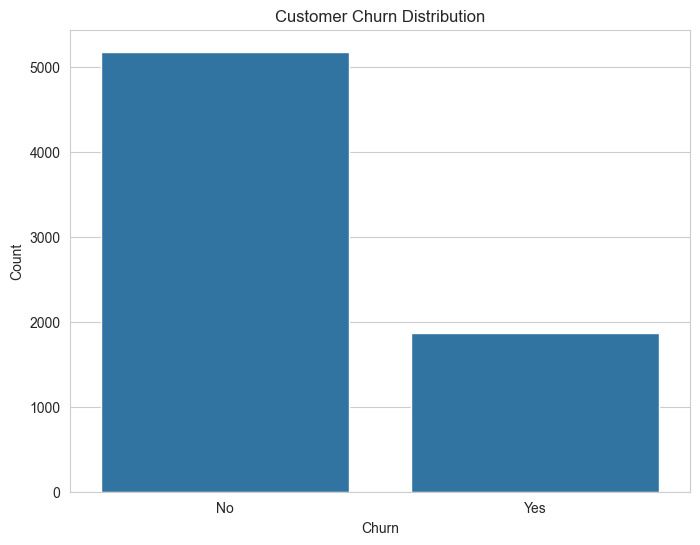

In [177]:
# Target Distribution: Churn
# Plot: Churn vs Count graph
plt.figure(figsize=(8,6))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

### Important Obeservation:
- There is imbalance in dataset: more No churn then Yes
- Appropriate evaluation metrics and possibly resampling or class-weighted models
- Recall on churn class is important 

In [178]:
# Churn Percentage
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [179]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("Numerical Features: ", numerical_features)
print("Categorical Features: ", categorical_features)

Numerical Features:  ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical Features:  ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


### Customer Demographics

### Gender vs Churn

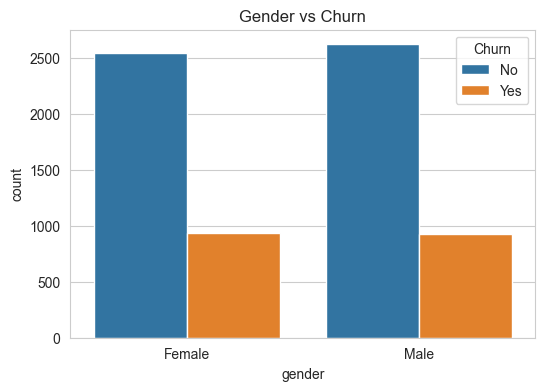

In [180]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Gender vs Churn")
plt.show()

### Observation
- Churn distribution appears similar across genders
- Gender alone may not be a strong predictor of churn (but it may interactwith other features)

### Senior Citizen vs Churn

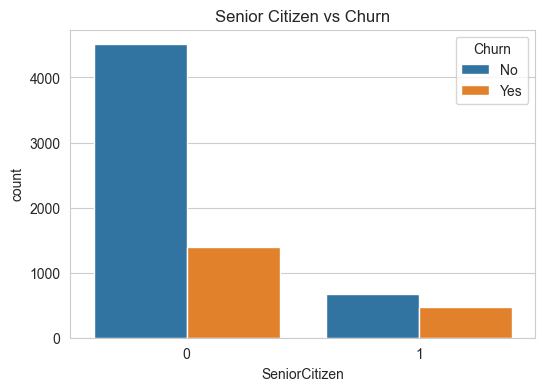

In [181]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title('Senior Citizen vs Churn')
plt.show()

### Observation
- Not senior citizen: 0, Yes senior citizen: 1
- Senior citizens appera to have a higher proportion of churn compared to non-senior customers
- Reason: Product fit, Pricing Sensitivity, or Service usability

### Contract Type vs Churn

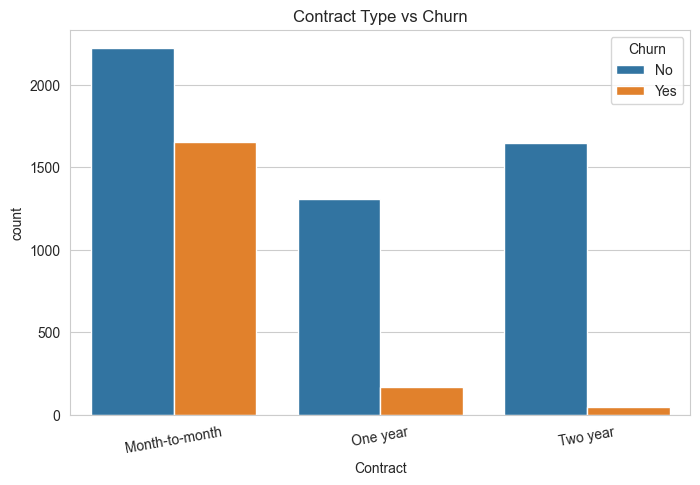

In [182]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=10)
plt.show()

### Observation
- Count: Month-to-Month > Two-Year > One-Year
- Customers with Month-to-Month contracts have significantly higher churn rate
- Longer Contracts (in terms of year) show lower churn (suggests contract length increases retention)

In [183]:
# Churn percentage by contract type
contract_churn_pct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn_pct.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


### Payment Method vs Churn

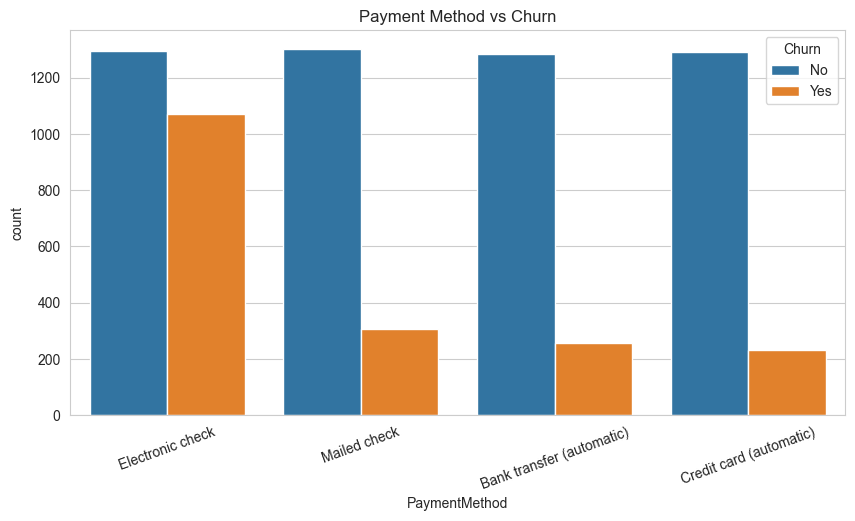

In [184]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=20)
plt.show()

### Observation
- Electronic checks show higher churn proportions
- Possible indications: failed payments, billing friction or differences in customer segments

### Tenure Distribution

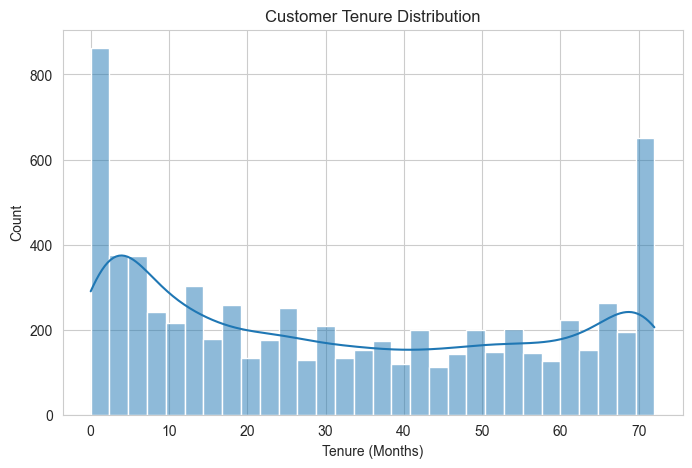

In [185]:
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.show()

### Observation
- Tenure distribution is skewed toward newer customers (shorter tenure).
- short-tenure customers are more likely to churn

### Monthly Charges vs Churn

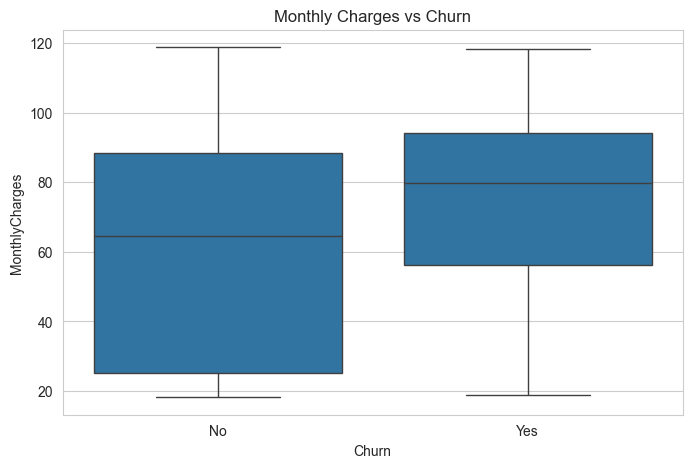

In [186]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

### Observations
- Customers with highly monthly charges tend to churn more often

### Internet Service vs Churn

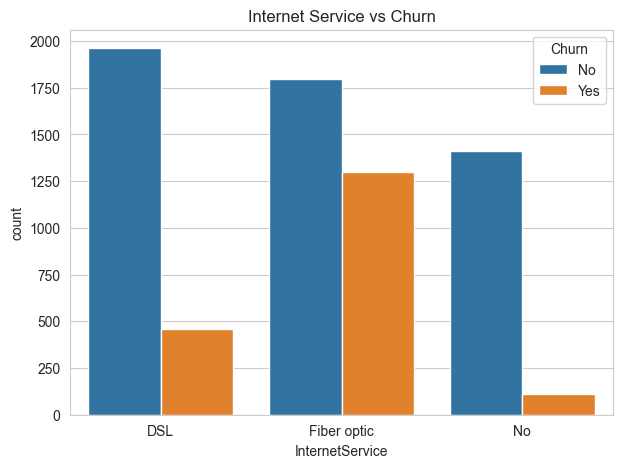

In [187]:
plt.figure(figsize=(7,5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

### Observation
- Customers opting for fibre optics have higher churn rate as compared to DSL

### Tech Support vs Churn

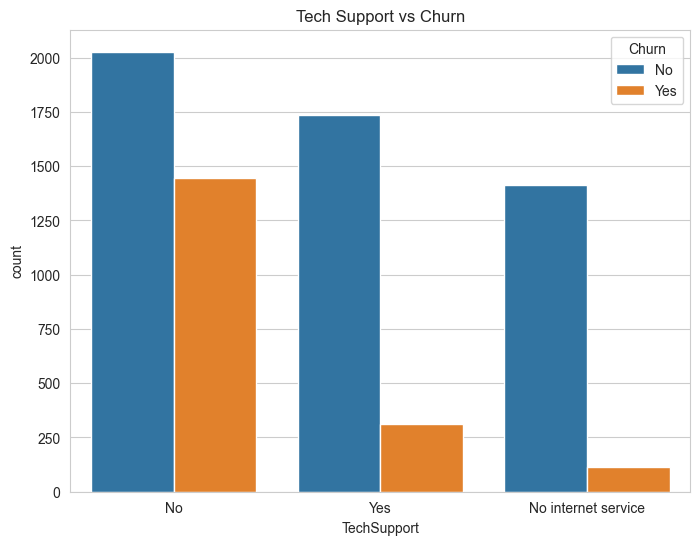

In [188]:
plt.figure(figsize=(8,6))
sns.countplot(x="TechSupport", hue="Churn", data=df)
plt.title("Tech Support vs Churn")
plt.show()

### Observation
- Customer with no tech support churn more often
- Support quality affects retention

### Tenure vs MonthlyCharges

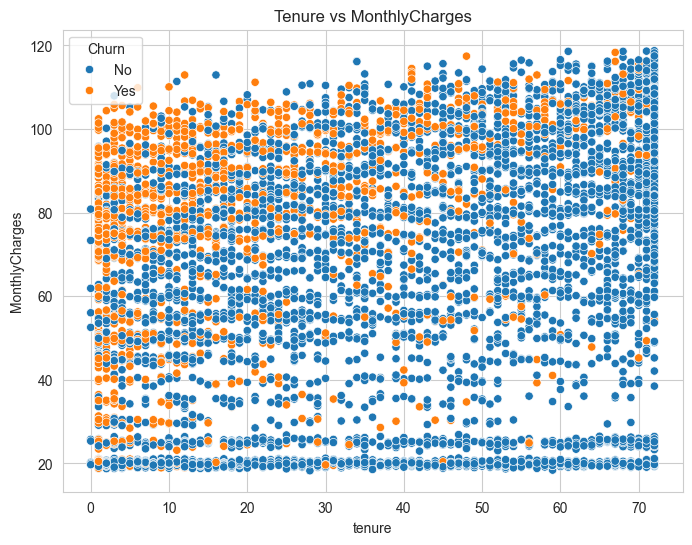

In [189]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="tenure", y="MonthlyCharges", hue="Churn", data=df)
plt.title("Tenure vs MonthlyCharges")
plt.show()

### Observation
- As the monthly charges increase for a new customer, the churn rate is also on the higher side
- Long time customers have a very less chance to churn

## Day-1 Summary
- Contract (month-to-month) → higher churn; Electronic check & Fiber Internet → higher churn; Higher MonthlyCharges correlates with churn; Senior citizens show elevated churn.
- TotalCharges has blank-string entries (hidden missing values)
- Added percentage-based analysis (crosstabs), boxplot for MonthlyCharges, churn-by-contract proportions, and targeted observations for each plot.

# Day-2: Data Cleaning + Feature Engineering
## Objectives
- Cleaned Dataset
- Handle Hidden missing values
- encode target variable
- Identify features that are important
- Prepare data for ML model

### Copy of Dataset

In [190]:
df_cleaned = df.copy()
print("Success: Dataset copied")

Success: Dataset copied


### Handle Hidden missing values in TotalCharges

In [191]:
# 1. Replace space with NaN
df_cleaned['TotalCharges'] = df_cleaned['TotalCharges'].replace(' ', np.nan)

# 2. Convert NaN to numeric
df_cleaned['TotalCharges'] = pd.to_numeric(df_cleaned['TotalCharges'])

#3. Check the data type
df_cleaned['TotalCharges'].dtype

#4. Check missing values
df_cleaned['TotalCharges'].isnull().sum()

#5. Now as there are only 11 values (containing 0), we can drop the same
df_cleaned.dropna(inplace=True)

print("Success: Missing values dropped")

Success: Missing values dropped


In [192]:
df_cleaned['TotalCharges'].isnull().sum()

0

### Remove Customer ID
- Unique values
- Can introduce noise in future

In [193]:
df_cleaned.drop('customerID', axis=1, inplace=True)
print("Success: Customer ID dropped")

Success: Customer ID dropped


### Encode Target Variable
- Yes -> 1
- No -> 0

In [194]:
df_cleaned['Churn'] = df_cleaned['Churn'].map({
    'Yes' : 1,
    'No' : 0
})

df_cleaned['Churn'].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

### Numerical and Categorical Features

In [195]:
numerical_features = df_cleaned.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = df_cleaned.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical Features: ", numerical_features)
print("Categoical Features: ", categorical_features)

Numerical Features:  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
Categoical Features:  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Unique values in categorical columns?
- Understand encoding needs
- Detect inconsistencies

In [196]:
for col in categorical_features:
    print(f"\nColumns: {col}")
    print(df_cleaned[col].unique())


Columns: gender
['Female' 'Male']

Columns: Partner
['Yes' 'No']

Columns: Dependents
['No' 'Yes']

Columns: PhoneService
['No' 'Yes']

Columns: MultipleLines
['No phone service' 'No' 'Yes']

Columns: InternetService
['DSL' 'Fiber optic' 'No']

Columns: OnlineSecurity
['No' 'Yes' 'No internet service']

Columns: OnlineBackup
['Yes' 'No' 'No internet service']

Columns: DeviceProtection
['No' 'Yes' 'No internet service']

Columns: TechSupport
['No' 'Yes' 'No internet service']

Columns: StreamingTV
['No' 'Yes' 'No internet service']

Columns: StreamingMovies
['No' 'Yes' 'No internet service']

Columns: Contract
['Month-to-month' 'One year' 'Two year']

Columns: PaperlessBilling
['Yes' 'No']

Columns: PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


### Binary Encoding (for yes/no features)

In [197]:
binary_columns = []

for col in categorical_features:
    if df_cleaned[col].nunique() == 2 and col != 'gender':
        binary_columns.append(col)

print(binary_columns)

['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']


In [198]:
for col in binary_columns:
    df_cleaned[col] = df_cleaned[col].map({
        'Yes' : 1,
        'No' : 0
    })

print("Success: Binary Encoding")

Success: Binary Encoding


### Note: We are not encoding gender in above cells (as it contains male and female)

### Encoding gender

In [199]:
df_cleaned['gender'] = df_cleaned['gender'].map({
    'Male' : 1,
    'Female' : 0
})

print("Success: Binary Encoding (Gender)")

Success: Binary Encoding (Gender)


### One-Hot Encoding (Remaining categorical features)

1. Check remaining object columns

In [200]:
remaining_categorical = df_cleaned.select_dtypes(
    include=['object']
).columns.tolist()

print(remaining_categorical)

['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


2. Apply One-Hot Encoding

In [201]:
df_encoded = pd.get_dummies(
    df_cleaned,
    columns = remaining_categorical,
    drop_first = True
)

print("Success: One-Hot Encoding")

Success: One-Hot Encoding


### Dataset check

In [202]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


### Converting boolean columns to 0/1

In [203]:
bool_columns = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)
print("Boolean columns converted successfully!")

Boolean columns converted successfully!


In [204]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [205]:
df_encoded.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV

In [206]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int32  
 11  MultipleL

### Dataset shape after encoding

In [207]:
print("final Dataset shape: ", df_encoded.shape)

final Dataset shape:  (7032, 31)


### Correlation Heatmap

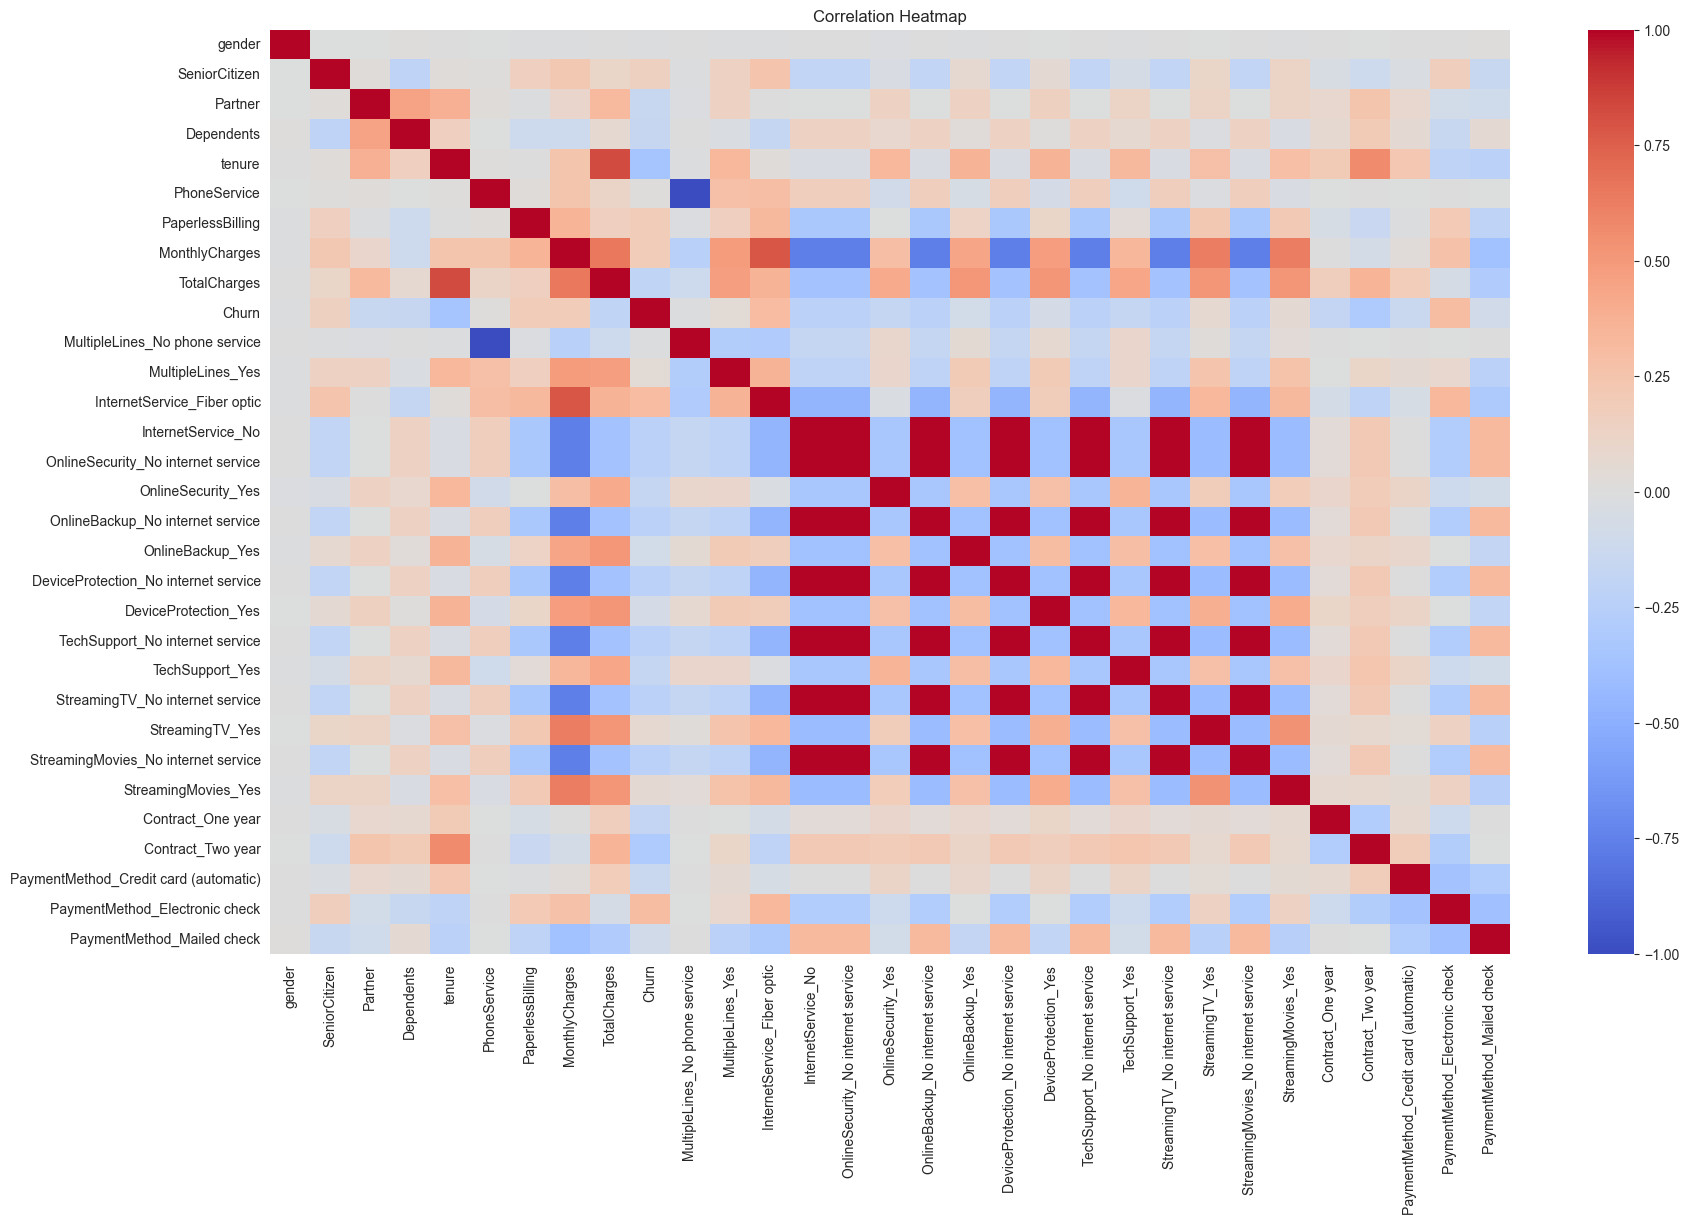

In [208]:
plt.figure(figsize=(20,12))
sns.heatmap(
    df_encoded.corr(),
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

### Correlation with Churn

In [209]:
churn_correlation = df_encoded.corr()['Churn'].sort_values(ascending=False)
print(churn_correlation)

Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192858
PaperlessBilling                         0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService                             0.011691
gender                                  -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner                                 -0.149982
Dependents                              -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity_Yes                      -0.171270


### Top positives Correlations

In [210]:
top_positives = churn_correlation.head(10)
print(top_positives)

Churn                             1.000000
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling                  0.191454
SeniorCitizen                     0.150541
StreamingTV_Yes                   0.063254
StreamingMovies_Yes               0.060860
MultipleLines_Yes                 0.040033
PhoneService                      0.011691
Name: Churn, dtype: float64


### Top negative correlations

In [211]:
top_negatives = churn_correlation.tail(10)
print(top_negatives)

TotalCharges                           -0.199484
OnlineSecurity_No internet service     -0.227578
OnlineBackup_No internet service       -0.227578
InternetService_No                     -0.227578
DeviceProtection_No internet service   -0.227578
TechSupport_No internet service        -0.227578
StreamingTV_No internet service        -0.227578
StreamingMovies_No internet service    -0.227578
Contract_Two year                      -0.301552
tenure                                 -0.354049
Name: Churn, dtype: float64


### Feature Engineering

Feature-1: Tenure Groups

In [212]:
df_encoded['tenure_group'] = pd.cut(
    df_encoded['tenure'],
    bins=[0,12,24,48,72],
    labels=[0,1,2,3]
)

In [213]:
df_encoded['tenure_group'] = df_encoded['tenure_group'].astype(int)

Feature-2: Average Charges Per Month

In [214]:
df_encoded['avg_charges_per_month'] = (
    df_encoded['TotalCharges'] / (df_encoded['tenure'] + 1)
)

Note: +1 in denominator is done to avoid division by zero case

Feature-3: Total Service Count

In [215]:
service_columns = [
    "PhoneService",
    "MultipleLines_Yes",
    "InternetService_Fiber optic",
    "OnlineSecurity_Yes",
    "OnlineBackup_Yes",
    "DeviceProtection_Yes",
    "TechSupport_Yes",
    "StreamingTV_Yes",
    "StreamingMovies_Yes"
]

existing_service_columns = [col for col in service_columns if col in df_encoded.columns]
missing_service_columns = [col for col in service_columns if col not in df_encoded.columns]

print("Using service columns:", existing_service_columns)
if missing_service_columns:
    print("Missing service columns:", missing_service_columns)

df_encoded["total_services"] = df_encoded[existing_service_columns].sum(axis=1)

Using service columns: ['PhoneService', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']


Note: We can't take into columns like "InternetService_No" as a service becuase logically it is not a service. (Summing dummy columns directly may create wierd interpretations)

### Dataset Check

In [216]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,avg_charges_per_month,total_services
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,14.925000,1
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,2,53.985714,3
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,36.050000,3
3,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,2,40.016304,3
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,50.550000,2


### Correlation check

In [217]:
new_corr = df_encoded.corr()['Churn'].sort_values(ascending=False)
print(new_corr.head(15))

Churn                             1.000000
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling                  0.191454
SeniorCitizen                     0.150541
avg_charges_per_month             0.070992
StreamingTV_Yes                   0.063254
StreamingMovies_Yes               0.060860
MultipleLines_Yes                 0.040033
PhoneService                      0.011691
total_services                    0.005927
gender                           -0.008545
MultipleLines_No phone service   -0.011691
DeviceProtection_Yes             -0.066193
Name: Churn, dtype: float64


### Feature Distribution Graphs

**Total Service Distribution**

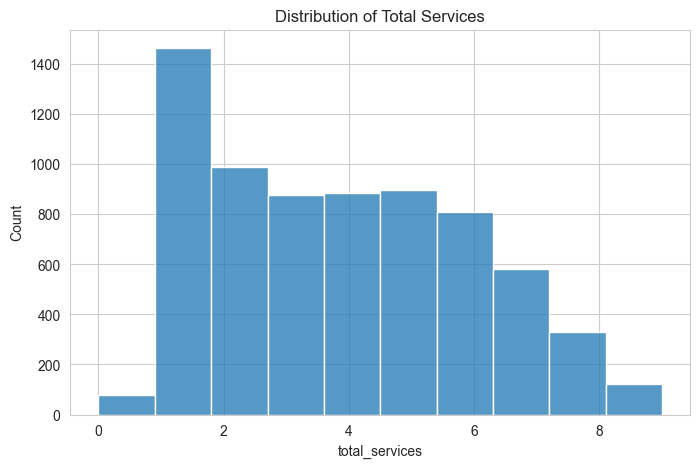

In [218]:
plt.figure(figsize=(8,5))
sns.histplot(df_encoded['total_services'], bins=10)
plt.title("Distribution of Total Services")
plt.show()

**Average Charges Distribution**

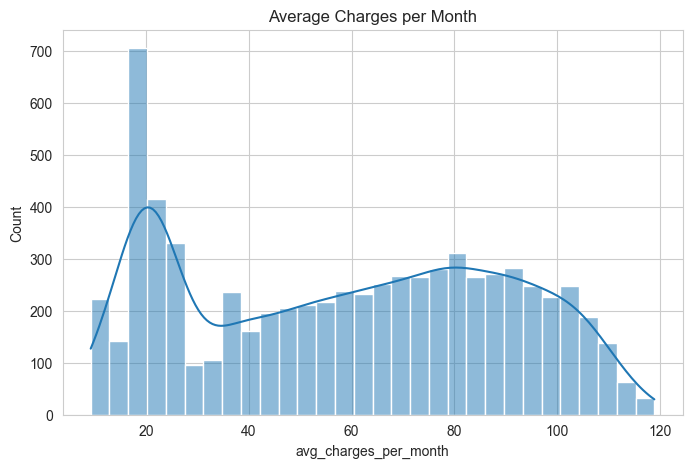

In [219]:
plt.figure(figsize=(8,5))
sns.histplot(df_encoded['avg_charges_per_month'], bins=30, kde=True)
plt.title("Average Charges per Month")
plt.show()

In [220]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 34 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int32  
 11  MultipleL

### Final Processed Dataset

In [221]:
df_encoded.to_csv("../data/processed_customer_churn.csv", index=False)
print("Success: Processed dataset saved")

Success: Processed dataset saved


## Day-2 Summary
- Proper Preprocessing
- Hidden missing value handling
- Safe encoding
- Feature Engineering
- Correlation Analysis
- Dataset Validation
- Processed Dataset export

# Day-3: Baseline ML Models + Evaluation Metrics

## Objectives
- Train/Test split
- Scaling
- Logistic Regression
- Random Forest
- ROC-AUC
- Precision-Recall
- Confusion Matrix
- Classification Report

### Import ML Libraries

In [222]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

print("Success: ML Libraries imported")

Success: ML Libraries imported


### Seperate Features and Target

In [223]:
# Features
X = df_encoded.drop('Churn', axis=1)

# Target
y = df_encoded['Churn']

print("Features shape: ", X.shape)
print("Target shape: ", y.shape)

Features shape:  (7032, 33)
Target shape:  (7032,)


### Train-Test Split
Here we would be using **stratify=y** because the dataset that we are using is imbalanced

In [224]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("Training Set Shape: ", X_train.shape)
print("Testing Set Shape: ", X_test.shape)

Training Set Shape:  (5625, 33)
Testing Set Shape:  (1407, 33)


### Feature Scaling
For now we would be scaling full dataset

In [225]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Success: Complete Feature scaling")

Success: Complete Feature scaling


Here we would only fit the train data because this prevents **Data Leakage**

### Evaluation Function

In [226]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Probabilities
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    return {
        "Accuracy" : accuracy,
        "Precision" : precision,
        "Recall" : recall,
        "F1 Score" : f1,
        "ROC-AUC" : roc_auc
    }

### Logistic Regression

In [227]:
log_reg = LogisticRegression(
    max_iter = 1000,
    random_state = 42
)

log_reg_results = evaluate_model(
    log_reg,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Accuracy: 0.7989
Precision: 0.6409
Recall: 0.5535
F1 Score: 0.5940
ROC-AUC: 0.8375


### Confusion Matrix (Logistic Regression)

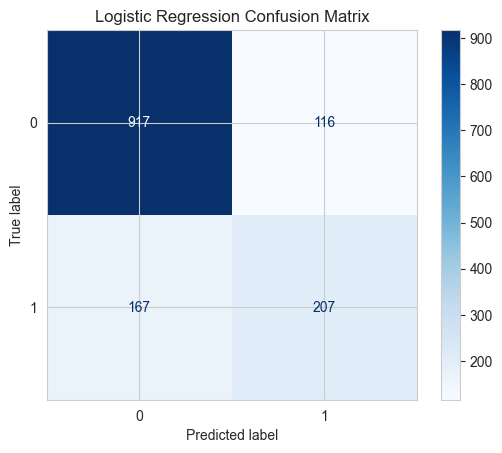

In [228]:
y_pred_log = log_reg.predict(X_test_scaled)

lr_cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix = lr_cm)

disp.plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### ROC Curve (Logistic Regression)

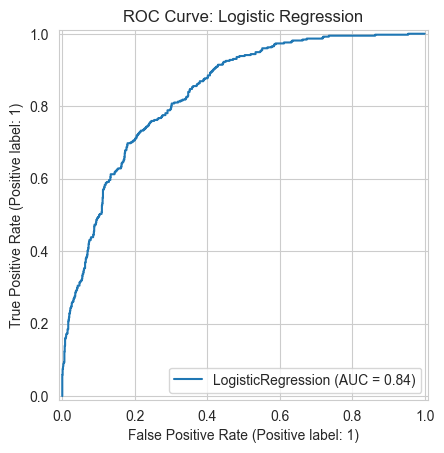

In [229]:
RocCurveDisplay.from_estimator(
    log_reg,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve: Logistic Regression")

plt.show()

### Logistic Regression Evaluation
**Accuracy** : 79.89
**Precision** : 64.09
**Recall** : 55.35
**F1** : 59.40
**ROC-AUC** : 83.75
**AUC** : 84

### Decision Tree Classifier

In [230]:
decision_tree = DecisionTreeClassifier(
    random_state = 42,
    max_depth = 5
)

decision_tree_results = evaluate_model(
    decision_tree,
    X_train,
    X_test,
    y_train,
    y_test
)

Accuracy: 0.7783
Precision: 0.5807
Recall: 0.5963
F1 Score: 0.5884
ROC-AUC: 0.8195


Note: Here as trees do not require scaling, so we would be using **X_train** instead of **X_train_scaled**

### Confusion Matrix (Decision Tree)

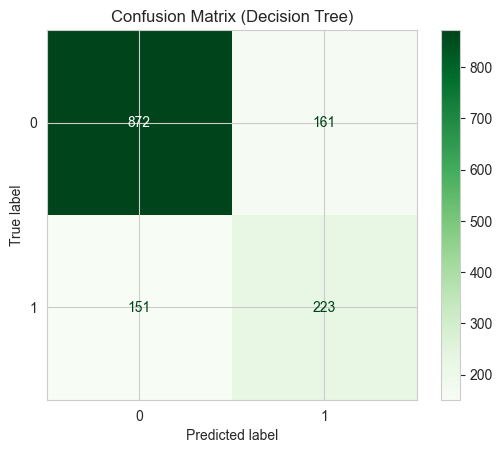

In [231]:
y_pred_dec = decision_tree.predict(X_test)

dt_cm = confusion_matrix(y_test, y_pred_dec)

dt_disp = ConfusionMatrixDisplay(confusion_matrix = dt_cm)

dt_disp.plot(cmap="Greens")

plt.title("Confusion Matrix (Decision Tree)")

plt.show()

### ROC Curve (Decision Tree Classifier)

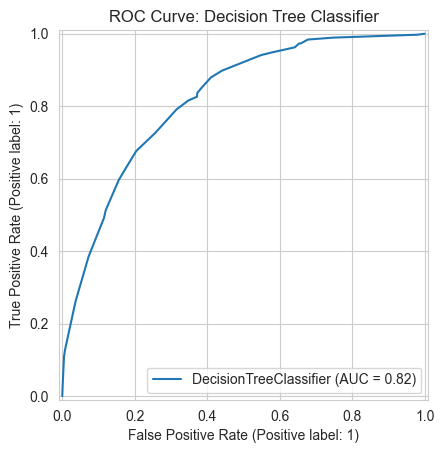

In [232]:
RocCurveDisplay.from_estimator(
    decision_tree,
    X_test,
    y_test
)

plt.title("ROC Curve: Decision Tree Classifier")

plt.show()

### Decision Tree Evaluation
**Accuracy** : 77.83
**Precision** : 58.07
**Recall** : 59.63
**F1** : 58.84
**ROC-AUC** : 81.95
**AUC** : 82

### Random Forest

In [233]:
random_forest = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    max_depth = 8
)

random_forest_results = evaluate_model(
    random_forest,
    X_train,
    X_test,
    y_train,
    y_test
)

Accuracy: 0.7889
Precision: 0.6370
Recall: 0.4786
F1 Score: 0.5466
ROC-AUC: 0.8364


### Confusion Matrix (Random Forest)

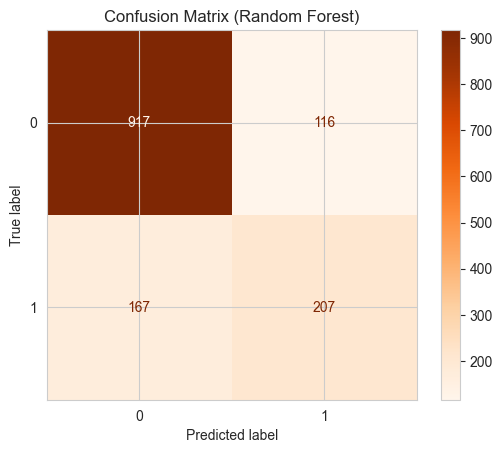

In [234]:
y_pred_rf = random_forest.predict(X_test)

rf_cm = confusion_matrix(y_test, y_pred_rf)

rf_disp = ConfusionMatrixDisplay(confusion_matrix = rf_cm)

disp.plot(cmap = "Oranges")

plt.title("Confusion Matrix (Random Forest)")

plt.show()

### ROC Curve (Random Forest)

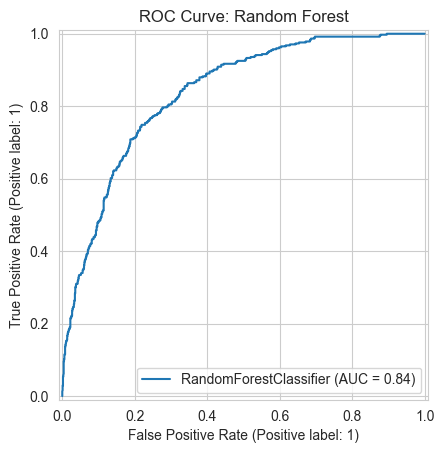

In [235]:
RocCurveDisplay.from_estimator(
    random_forest,
    X_test,
    y_test
)

plt.title("ROC Curve: Random Forest")

plt.show()

### Random Forest Evaluation
**Accuracy** : 78.89
**Precision** : 63.70
**Recall** : 47.86
**F1** : 54.66
**ROC-AUC** : 83.64
**AUC** : 84

### Compare Models

In [236]:
results_df = pd.DataFrame({
    "Logistic Regression" : log_reg_results,
    "Decision Tree" : decision_tree_results,
    "Random Forest" : random_forest_results
})

results_df

,Logistic Regression,Decision Tree,Random Forest
Accuracy,0.798863,0.778252,0.788913
Precision,0.640867,0.580729,0.637011
Recall,0.553476,0.596257,0.478610
F1 Score,0.593974,0.588391,0.546565
ROC-AUC,0.837523,0.819510,0.836376


### Visualized version of results

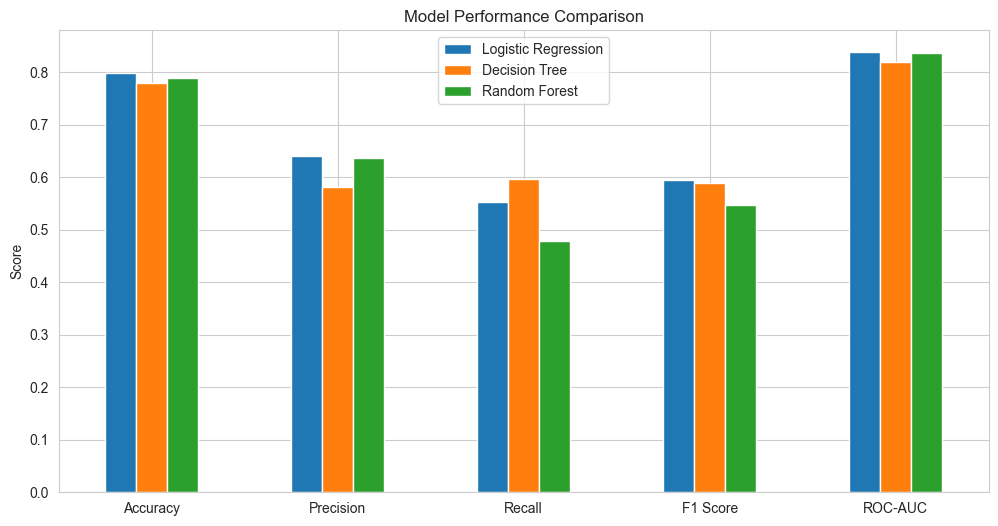

In [237]:
results_df.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

### Feature Importance

**Random Forest**

In [238]:
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,tenure,0.153223
8,TotalCharges,0.109416
30,tenure_group,0.097041
7,MonthlyCharges,0.082881
11,InternetService_Fiber optic,0.075813
31,avg_charges_per_month,0.071622
26,Contract_Two year,0.063846
28,PaymentMethod_Electronic check,0.055759
25,Contract_One year,0.029446
14,OnlineSecurity_Yes,0.026467


In [239]:
feature_importance.tail(10)

,Feature,Importance
1,SeniorCitizen,0.008834
0,gender,0.007105
2,Partner,0.006872
22,StreamingTV_Yes,0.006721
24,StreamingMovies_Yes,0.006437
29,PaymentMethod_Mailed check,0.005474
27,PaymentMethod_Credit card (automatic),0.005108
18,DeviceProtection_Yes,0.004647
9,MultipleLines_No phone service,0.002641
5,PhoneService,0.002615


**Visualize Top Features**

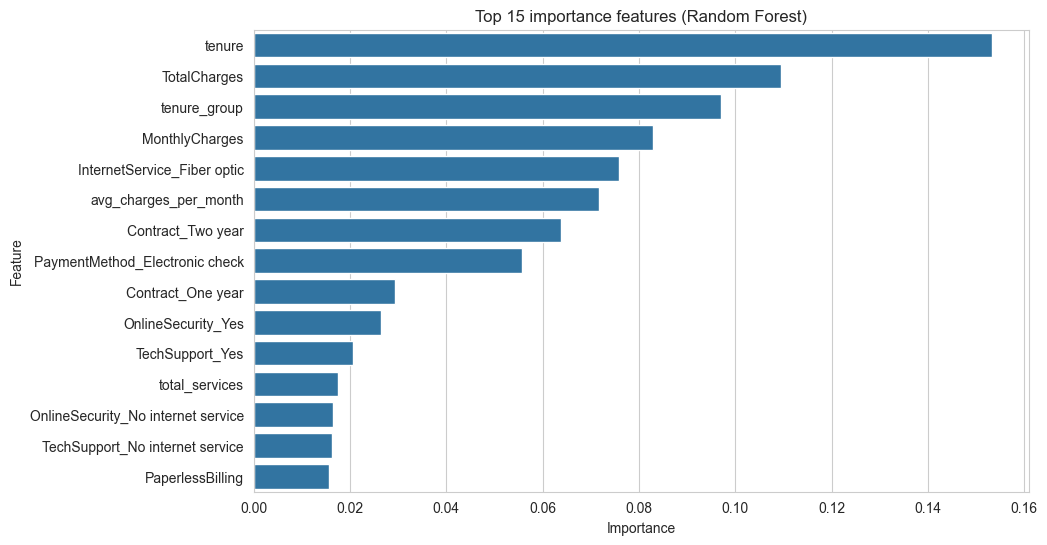

In [240]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title("Top 15 importance features (Random Forest)")

plt.show()

**Logistic Regression**

In [241]:
feature_importance_log_reg = pd.DataFrame({
    'Feature' : X.columns,
    'Coefficient' : log_reg.coef_[0]
})

feature_importance_log_reg = feature_importance_log_reg.sort_values(
    by='Coefficient',
    ascending=False
)

feature_importance_log_reg.head(15)

,Feature,Coefficient
11,InternetService_Fiber optic,0.882403
8,TotalCharges,0.559586
32,total_services,0.320498
22,StreamingTV_Yes,0.288110
24,StreamingMovies_Yes,0.282552
10,MultipleLines_Yes,0.232371
28,PaymentMethod_Electronic check,0.160624
6,PaperlessBilling,0.139965
1,SeniorCitizen,0.071014
18,DeviceProtection_Yes,0.065093


In [242]:
feature_importance_log_reg.tail(10)

,Feature,Coefficient
19,TechSupport_No internet service,-0.103095
12,InternetService_No,-0.103095
20,TechSupport_Yes,-0.112179
30,tenure_group,-0.116360
14,OnlineSecurity_Yes,-0.137185
25,Contract_One year,-0.337130
7,MonthlyCharges,-0.337782
26,Contract_Two year,-0.714060
4,tenure,-0.863667
31,avg_charges_per_month,-1.192831


**Visualize Top Coefficients**

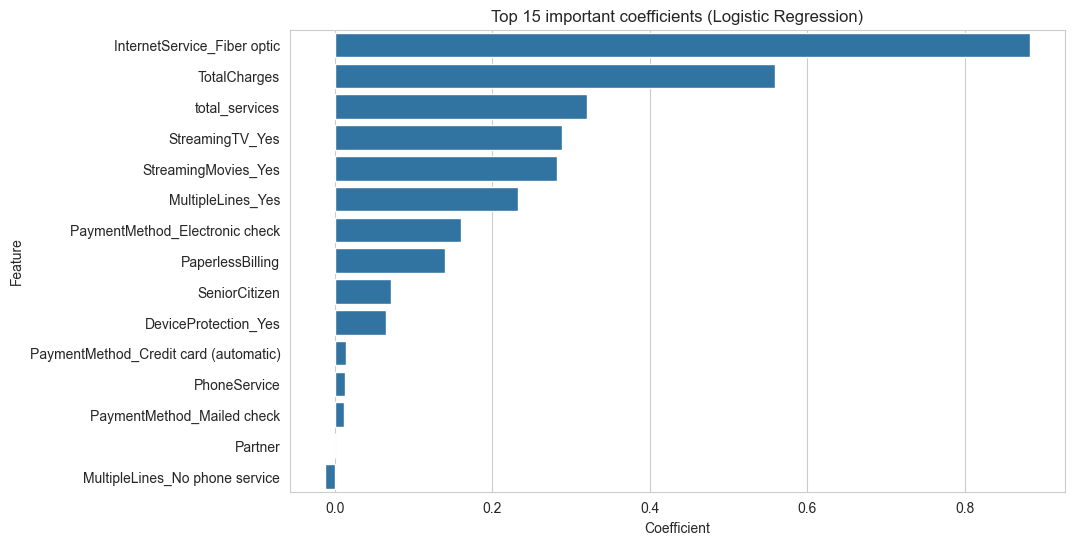

In [243]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=feature_importance_log_reg.head(15)
)

plt.title("Top 15 important coefficients (Logistic Regression)")

plt.show()

**Decision Tree**

In [244]:
feature_importance_decision_tree = pd.DataFrame({
    'Feature' : X.columns,
    'Importance' : decision_tree.feature_importances_
})

feature_importance_decision_tree = feature_importance_decision_tree.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_decision_tree.head(15)

,Feature,Importance
4,tenure,0.441283
11,InternetService_Fiber optic,0.338826
8,TotalCharges,0.033886
28,PaymentMethod_Electronic check,0.026809
23,StreamingMovies_No internet service,0.026778
7,MonthlyCharges,0.025198
26,Contract_Two year,0.019312
19,TechSupport_No internet service,0.015402
14,OnlineSecurity_Yes,0.015138
20,TechSupport_Yes,0.012159


**Visualize Top Features**

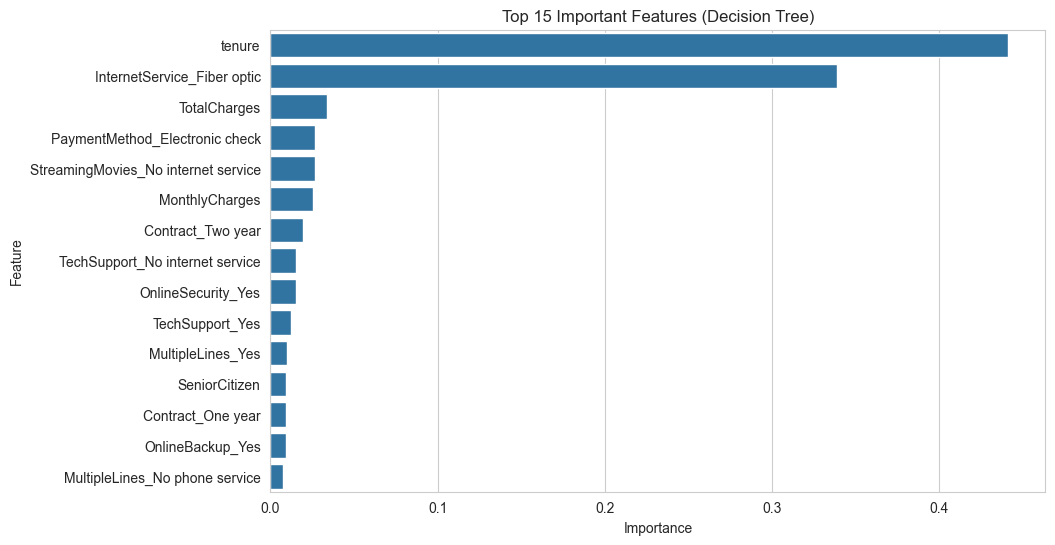

In [245]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_decision_tree.head(15)
)

plt.title("Top 15 Important Features (Decision Tree)")

plt.show()

### Classification Report

**Random Forest**

In [246]:
print(classification_report(y_test, random_forest.predict(X_test)))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



**Logistic Regression**

In [247]:
print(classification_report(y_test, log_reg.predict(X_test_scaled)))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



**Decision Tree**

In [248]:
print(classification_report(y_test, decision_tree.predict(X_test)))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



## Observations

### Model Performance Comparison
3 Baseline Machine Leanring Models used for evaluation of Customer churn
- Logistic Regression
- Decision Tree
- Random Forest

Among them, **Logistic Regression** was the standout model with
- Highest Accuracy score
- Highest F1-score
- Higest ROC-AUC score

This indicates that the customer churn dataset exhibits relatively structured and linearly separable patterns, allowing Logistic Regression to generalize effectively.

Although ensemble models like Random Forest are often expected to outperform simpler models, this is not always guaranteed. In structured tabular datasets with strong predictive features, simpler linear models can perform competitively or even better.

### Precision vs Recall Tradeoff
**Logistic Regression**
- Better overall balance between precision and recall.
- Lower recall than Decision Tree but higher precision.

**Decision Tree**
- Highest recall among the three models.
- Captures more actual churners.
- However, it also produces more false positives.

**Random Forest**
- Strong ROC-AUC score.
- Higher precision compared to Decision Tree.
- Lower recall, meaning more actual churners are missed.

### Why Recall is important in Customer Churn
Recall is one of the most critical evaluation metrics.

Recall measures:

- Out of all customers who actually churned, how many were correctly identified?

In real business scenarios:

- False Negatives are expensive.
- A False Negative occurs when:
    - the model predicts that a customer will stay, but the customer actually churns.

This leads to:
customer loss, revenue loss, increased acquisition costs, and reduced customer lifetime value.

### Why ROC-AUC matters?
ROC-AUC measures the model’s ability to distinguish between churn and non-churn customers across multiple classification thresholds.

A higher ROC-AUC score indicates:

- stronger ranking capability,
- better class separation,
- and more reliable probability predictions.

All three models achieved relatively strong ROC-AUC scores (~0.82–0.84), indicating that the preprocessing and feature engineering pipeline successfully captured meaningful customer behavior patterns.

## Day-3 Summary
- Train/Test split
- Scaling
- Logistic Regression
- Random Forest
- ROC-AUC
- Precision-Recall
- Confusion Matrix
- Classification Report

# Day-4: Advanced Models + Hyperparameter Tuning + Kaggle Submission Optimization

## Observations
- XGBoost/LightGBM/CatBoost
- GridSearchCV
- RandomizedSearchCV
- threshold tuning
- leaderboard optimization
- model improvement

### Import Libraries

In [249]:
%pip install catboost lightgbm xgboost

# Cross Validation
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV

# Models
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import joblib

print("Success: Libraries imported")

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: catboost in c:\users\kaust\appdata\local\programs\python\python311\lib\site-packages (1.2.10)

Success: Libraries imported



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### XGBoost

In [250]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_results = evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Accuracy: 0.7932
Precision: 0.6293
Recall: 0.5401
F1 Score: 0.5813
ROC-AUC: 0.8309


### XGBoost Evaluation:
**Accuracy** : 79.18
**Precision** : 62.46
**Recall** : 54.28
**F1** : 58.08
**ROC-AUC** : 83.10

### LightGBM

In [251]:
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

lgbm_results = evaluate_model(
    lgbm_model,
    X_train,
    X_test,
    y_train,
    y_test
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001563 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 906
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

### LightGBM Evaluation
**Accuracy** : 79.25
**Precision** : 62.65
**Recall** : 54.28
**F1** : 58.17
**ROC-AUC** : 83.53

### CatBoost

In [252]:
catboost_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    verbose=0,
    random_state=42
)

catboost_results = evaluate_model(
    catboost_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Accuracy: 0.7903
Precision: 0.6312
Recall: 0.5080
F1 Score: 0.5630
ROC-AUC: 0.8364


### Catboost Evaluation
**Accuracy** : 79.03
**Precision** : 63.12
**Recall** : 50.80
**F1** : 56.30
**ROC-AUC** : 83.64

### Compare Advanced models

In [253]:
advanced_results = pd.DataFrame({
    'XGBoost' : xgb_results,
    'lightGBM' : lgbm_results,
    'CatBoost' : catboost_results
}).T

advanced_results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
XGBoost,0.793177,0.629283,0.540107,0.581295,0.830945
lightGBM,0.792466,0.626543,0.542781,0.581662,0.835340
CatBoost,0.790334,0.631229,0.508021,0.562963,0.836387


### Comparison Plot

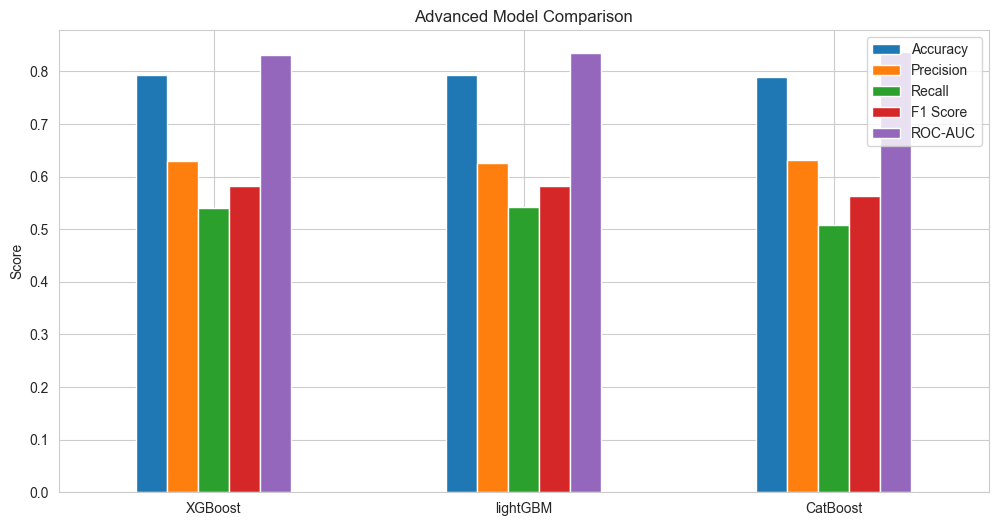

In [254]:
advanced_results.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Advanced Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

### Compare All Models

In [255]:
all_results = pd.DataFrame({
    'Logistic Regression' : log_reg_results,
    'Decision Tree' : decision_tree_results,
    'Random Forest' : random_forest_results,
    'XGBoost' : xgb_results,
    'LightGBM' : lgbm_results,
    'CatBoost' : catboost_results
}).T

all_results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.798863,0.640867,0.553476,0.593974,0.837523
Decision Tree,0.778252,0.580729,0.596257,0.588391,0.819510
Random Forest,0.788913,0.637011,0.478610,0.546565,0.836376
XGBoost,0.793177,0.629283,0.540107,0.581295,0.830945
LightGBM,0.792466,0.626543,0.542781,0.581662,0.835340
CatBoost,0.790334,0.631229,0.508021,0.562963,0.836387


### All Model Comparison Plot

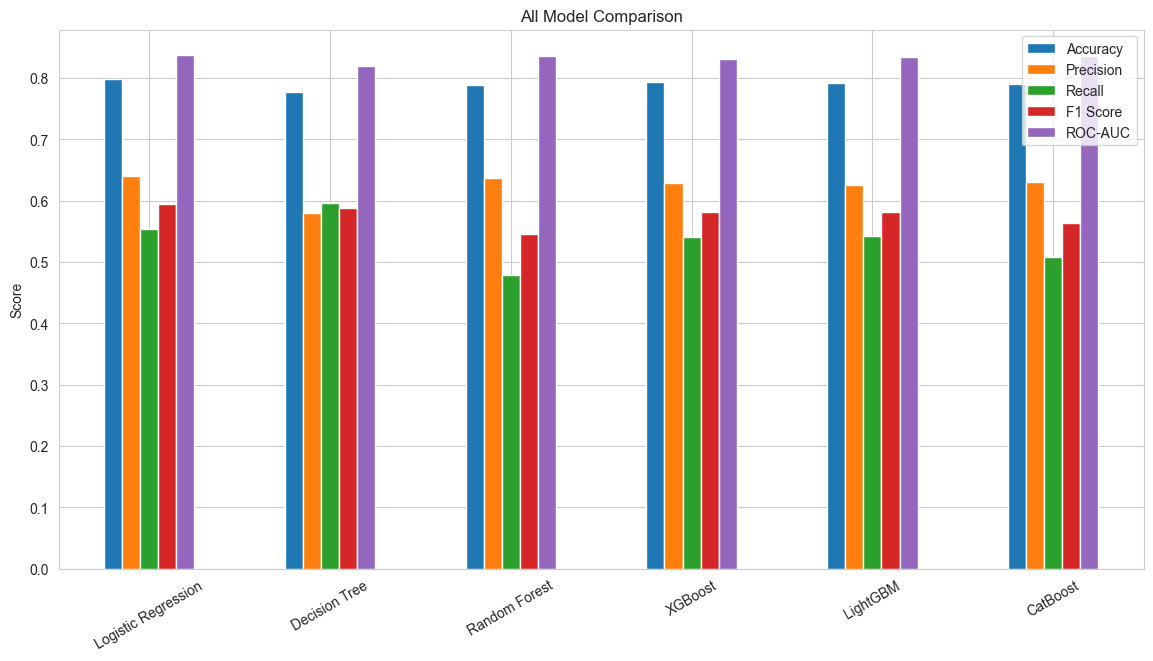

In [256]:
all_results.plot(
    kind='bar',
    figsize=(14,7)
)

plt.title("All Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)

plt.show()

### Observations
1. Logistic Regression is still the best model overall
   - It wins Accuracy, Precision, F1, ROC-AUC
   - Remains competitve in Recall
   - Balanced Model
2. Decision Tree has the highest recall
   - Decision Tree catches the most churners (Highest Recall)
   - But Decision Tree sacrifies Precision, Recall, and ROC-AUC
3. Among the advanced boosting models, LightGBM delivered the strongest overall performance and came closest to Logistic Regression
4. Complex models did not outperform Logistic Regression
   This is because dataset is:
   - structured
   - relatively clean
   - moderate size (~7000 Rows)
   - Strong linear relationships

**I evaluated six different machine learning models and found that a simpler model generalized better than more complex ensemble methods.**

### Tune Models
- Logistic Regression
- LightGBM


### Parameter Grid

In [257]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    'C' : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty' : ['l1', 'l2'],
    'solver' : ['liblinear'],
    'class_weight' : [None, 'balanced']
}

### Grid Search

In [258]:
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)

print("Best Parameters: ")
print(lr_grid.best_params_)

print("\nBest CV ROC-AUC")
print(lr_grid.best_score_)

Best Parameters: 
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best CV ROC-AUC
0.8491432296517043


### Tuned Logistic Regression Evaluation

In [259]:
best_lr = lr_grid.best_estimator_

best_lr_results = evaluate_model(
    best_lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Accuracy: 0.7292
Precision: 0.4942
Recall: 0.7968
F1 Score: 0.6100
ROC-AUC: 0.8365


### Tuned Logistic Regression Evaluations
**Accuracy** : 72.92
**Precision** : 49.42
**Recall** : 79.68
**F1** : 61.00
**ROC-AUC** : 83.65

### Parameter Grid

In [260]:
lgbm_param_grid = {
    'n_estimators' : [100, 200, 300],
    'learning_rate' : [0.01, 0.05, 0.1],
    'max_depth' : [3, 5, 7, -1],
    'num_leaves' : [15, 31, 63]
}

### Random Search

In [261]:
from sklearn.model_selection import RandomizedSearchCV

lgbm_random = RandomizedSearchCV(
    LGBMClassifier(random_state=42),
    param_distributions=lgbm_param_grid,
    n_iter=15,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

lgbm_random.fit(X_train, y_train)

print("Best Parameters: ")
print(lgbm_random.best_params_)

print("\nBest CV ROC-AUC: ")
print(lgbm_random.best_score_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002404 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 906
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best Parameters: 
{'num_leaves': 15, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}

Best CV ROC-AUC: 
0.8469247775069441


### tuned LightGBM Evaluations

In [262]:
best_lgbm = lgbm_random.best_estimator_

best_lgbm_results = evaluate_model(
    best_lgbm,
    X_train,
    X_test,
    y_train,
    y_test
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000536 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 906
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Accuracy: 0.7932
Precision: 0.6293
Recall: 0.5401
F1 Score: 0.5813
ROC-AUC: 0.8402


### Tuned LightGBM Evaluations
**Accuracy** : 79.32
**Precision** : 62.93
**Recall** : 54.01
**F1** : 58.13
**ROC-AUC** : 84.02

### Compare Baseline vs Tuned Models

In [263]:
final_comparison = pd.DataFrame({
    "Baseline Logistic Regression" : log_reg_results,
    "Tuned Logistic Regression" : best_lr_results,
    "Baseline LightGBM" : lgbm_results,
    "Tuned LightGBM" : best_lgbm_results
}).T

final_comparison

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Baseline Logistic Regression,0.798863,0.640867,0.553476,0.593974,0.837523
Tuned Logistic Regression,0.729211,0.494196,0.796791,0.610031,0.836535
Baseline LightGBM,0.792466,0.626543,0.542781,0.581662,0.835340
Tuned LightGBM,0.793177,0.629283,0.540107,0.581295,0.840156


### Visualization

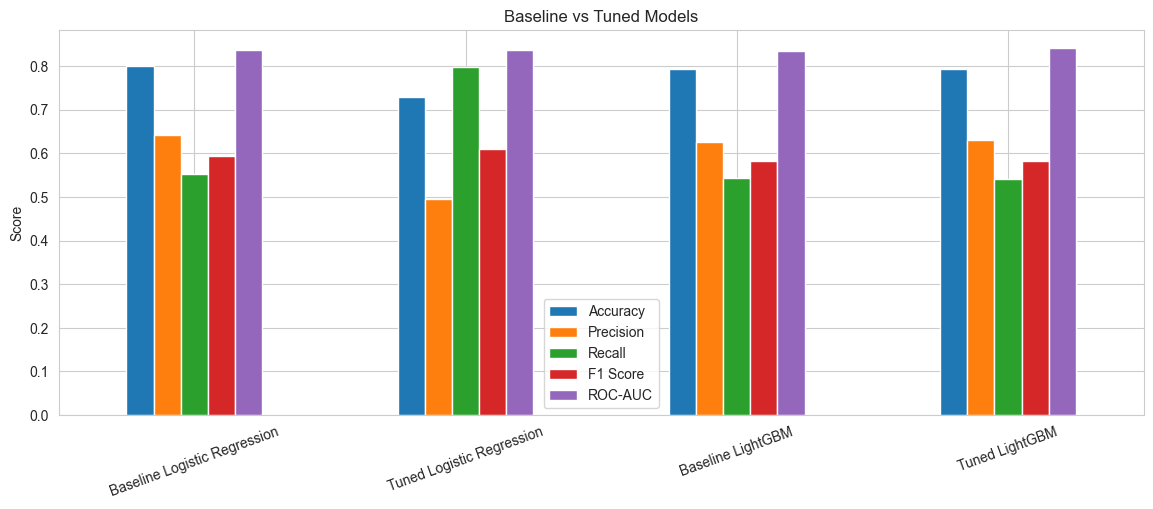

In [264]:
final_comparison.plot(
    kind='bar',
    figsize=(14,5)
)

plt.title("Baseline vs Tuned Models")
plt.ylabel("Score")
plt.xticks(rotation=20)

plt.show()

### Conclusion
Although the baseline Logistic Regression model achieved the highest accuracy and precision, the tuned Logistic Regression model significantly improved recall from 55.3% to 79.7% while maintaining a similar ROC-AUC score. Since the primary objective of churn prediction is to identify as many at-risk customers as possible, the tuned Logistic Regression model was selected as the final model. The increased recall reduces the likelihood of missing customers who are likely to churn, making it more suitable for customer retention initiatives.

### Threshold optimization

### Generate Probabilities for Tuned Logistic Regression and baseline Logistic Regression

In [265]:
print(type(best_lr))
print(type(log_reg))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [266]:
y_prob_tlr = best_lr.predict_proba(X_test_scaled)[:, 1]
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

In [267]:
# Tuned Logistic Regression
thresholds = [0.3, 0.4, 0.45, 0.5, 0.55, 0.6]

for threshold in thresholds:

    y_pred = (y_prob_tlr >= threshold).astype(int)

    print(f"\nThreshold = {threshold}")

    print(
        "Precision:",
        precision_score(y_test, y_pred)
    )

    print(
        "Recall:",
        recall_score(y_test, y_pred)
    )

    print(
        "F1:",
        f1_score(y_test, y_pred)
    )


Threshold = 0.3
Precision: 0.4222766217870257
Recall: 0.9224598930481284
F1: 0.5793450881612091

Threshold = 0.4
Precision: 0.4504881450488145
Recall: 0.8636363636363636
F1: 0.5921173235563703

Threshold = 0.45
Precision: 0.46986089644513135
Recall: 0.8128342245989305
F1: 0.5954946131243879

Threshold = 0.5
Precision: 0.494195688225539
Recall: 0.7967914438502673
F1: 0.6100307062436029

Threshold = 0.55
Precision: 0.5259259259259259
Recall: 0.7593582887700535
F1: 0.6214442013129103

Threshold = 0.6
Precision: 0.5512295081967213
Recall: 0.7192513368983957
F1: 0.6241299303944315


In [268]:
# Baseline Logistic Regression
thresholds = [0.3, 0.4, 0.45, 0.5, 0.55, 0.6]

for threshold in thresholds:

    y_pred = (y_prob_lr >= threshold).astype(int)

    print(f"\nThreshold = {threshold}")

    print(
        "Precision:",
        precision_score(y_test, y_pred)
    )

    print(
        "Recall:",
        recall_score(y_test, y_pred)
    )

    print(
        "F1:",
        f1_score(y_test, y_pred)
    )


Threshold = 0.3
Precision: 0.5230202578268877
Recall: 0.7593582887700535
F1: 0.6194111232279171

Threshold = 0.4
Precision: 0.5852534562211982
Recall: 0.679144385026738
F1: 0.6287128712871287

Threshold = 0.45
Precision: 0.6090425531914894
Recall: 0.6122994652406417
F1: 0.6106666666666667

Threshold = 0.5
Precision: 0.6408668730650154
Recall: 0.553475935828877
F1: 0.593974175035868

Threshold = 0.55
Precision: 0.6535433070866141
Recall: 0.44385026737967914
F1: 0.5286624203821656

Threshold = 0.6
Precision: 0.673469387755102
Recall: 0.35294117647058826
F1: 0.4631578947368421


### Coefficient DataFrame

In [269]:
coef_df = pd.DataFrame({
    'Feature' : X.columns,
    'Coefficient' : log_reg.coef_[0]
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

coef_df.head()

,Feature,Coefficient
11,InternetService_Fiber optic,0.882403
8,TotalCharges,0.559586
32,total_services,0.320498
22,StreamingTV_Yes,0.288110
24,StreamingMovies_Yes,0.282552


### Top Features Increasing Churn

In [270]:
top_positives = coef_df.head(15)

top_positives

,Feature,Coefficient
11,InternetService_Fiber optic,0.882403
8,TotalCharges,0.559586
32,total_services,0.320498
22,StreamingTV_Yes,0.288110
24,StreamingMovies_Yes,0.282552
10,MultipleLines_Yes,0.232371
28,PaymentMethod_Electronic check,0.160624
6,PaperlessBilling,0.139965
1,SeniorCitizen,0.071014
18,DeviceProtection_Yes,0.065093


### Visualization

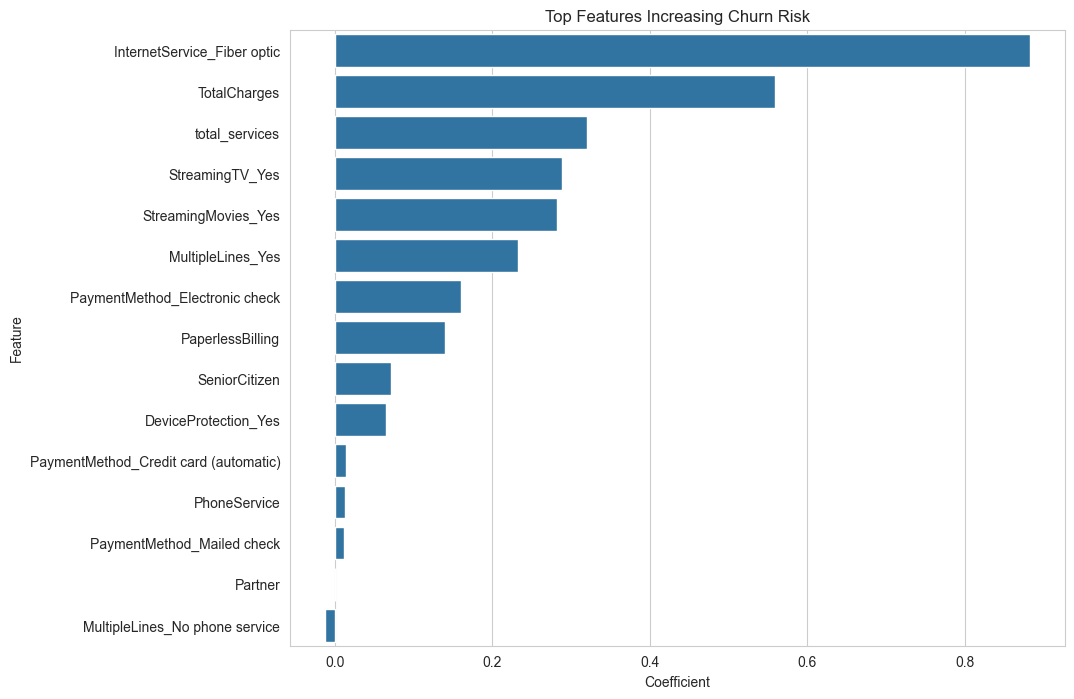

In [271]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=top_positives,
    x='Coefficient',
    y='Feature'
)

plt.title("Top Features Increasing Churn Risk")

plt.show()

### Features Reducing Churn

In [272]:
top_negative = coef_df.tail(15)

top_negative

,Feature,Coefficient
13,OnlineSecurity_No internet service,-0.103095
17,DeviceProtection_No internet service,-0.103095
23,StreamingMovies_No internet service,-0.103095
15,OnlineBackup_No internet service,-0.103095
21,StreamingTV_No internet service,-0.103095
19,TechSupport_No internet service,-0.103095
12,InternetService_No,-0.103095
20,TechSupport_Yes,-0.112179
30,tenure_group,-0.116360
14,OnlineSecurity_Yes,-0.137185


### Visualization

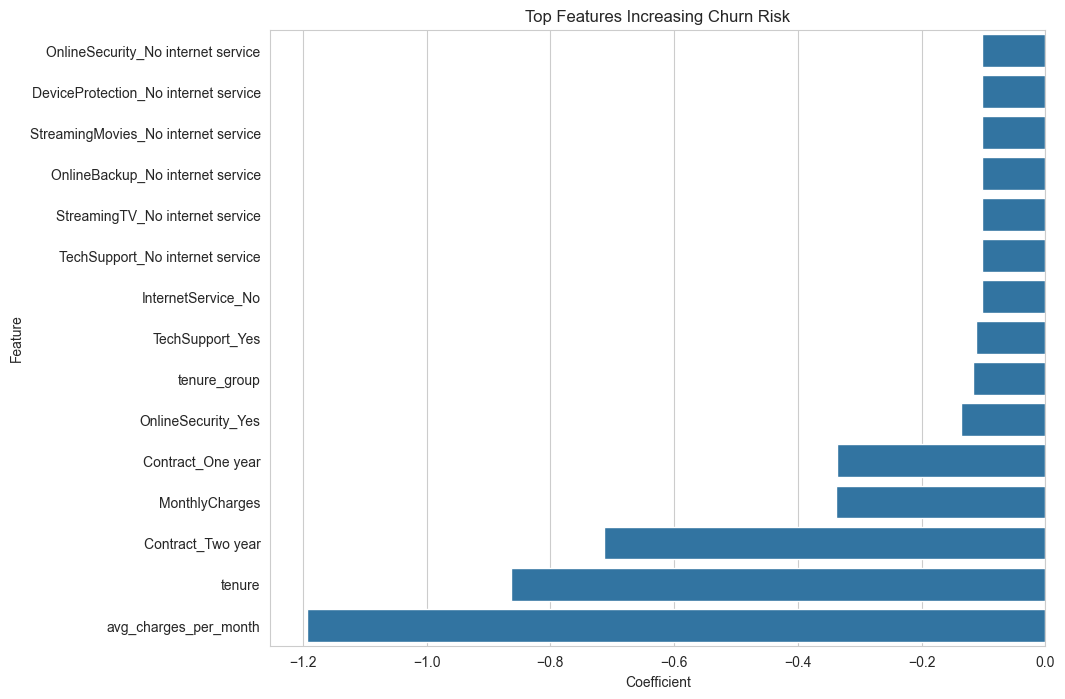

In [273]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=top_negative,
    x='Coefficient',
    y='Feature'
)

plt.title("Top Features Increasing Churn Risk")

plt.show()

### Cross Validation

In [274]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    log_reg,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("ROC-AUC Scores: ")
print(cv_scores)

print("\nAverage ROC-AUC: ")
print(cv_scores.mean())

print("\nStandard Deviation: ")
print(cv_scores.std())

ROC-AUC Scores: 
[0.83844048 0.87756606 0.84461522 0.82176261 0.8628884 ]

Average ROC-AUC: 
0.8490545563500611

Standard Deviation: 
0.019398440059308745


### Save Model

In [275]:
final_threshold = 0.40

In [309]:
import joblib

joblib.dump(
    log_reg, "../models/customer_churn_logistic_regression.pkl"
)

print("Success: Model Saved")

Success: Model Saved


### Save Scaler

In [310]:
joblib.dump(
    scaler, "../models/customer_churn_scaler.pkl"
)

print("Success: Scaler Saved")

Success: Scaler Saved


## Day-4 Summary
- Advanced Models
- Hyperparameter Tuning
- Threshold Optimization
- Feature Interpretation
- Cross Validation
- Model Persistance
- Final Model Selection

## Observations
Some billing-related variables exhibited coefficient directions that differed from initial EDA findings. This is likely due to multicollinearity among engineered and original billing features. Since Logistic Regression estimates the independent contribution of each feature while controlling for others, coefficient signs may differ from simple univariate relationships observed during exploratory analysis.

# Day-5: Explainability + Business Insights

## Objectives
- SHAP Explainability
- Error Analysis
- False Positive Analysis
- False Negative Analysis
- Business Recommendations
- Executive Summary
- Final Project Summary

### Import SHAP

In [278]:
import shap

print("Success: SHAP Imported")

Success: SHAP Imported


### SHAP Explainer

In [279]:
explainer = shap.LinearExplainer(
    log_reg,
    X_train_scaled
)

shap_values = explainer.shap_values(
    X_test_scaled
)

### Global Feature Importance

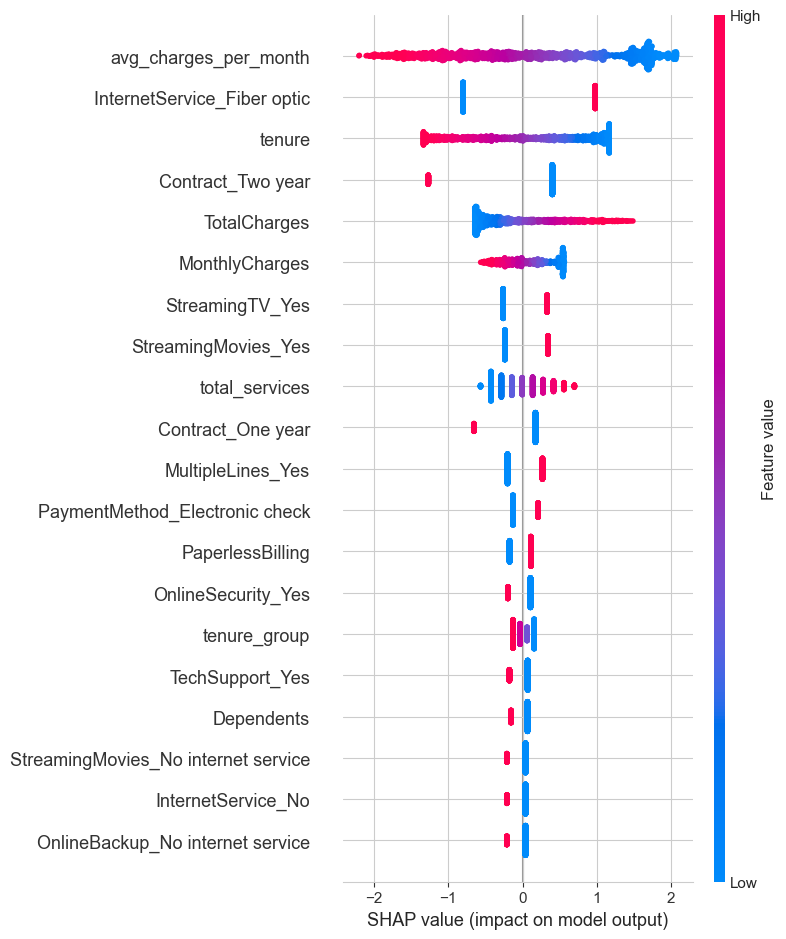

In [280]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns
)

### Bar Plot

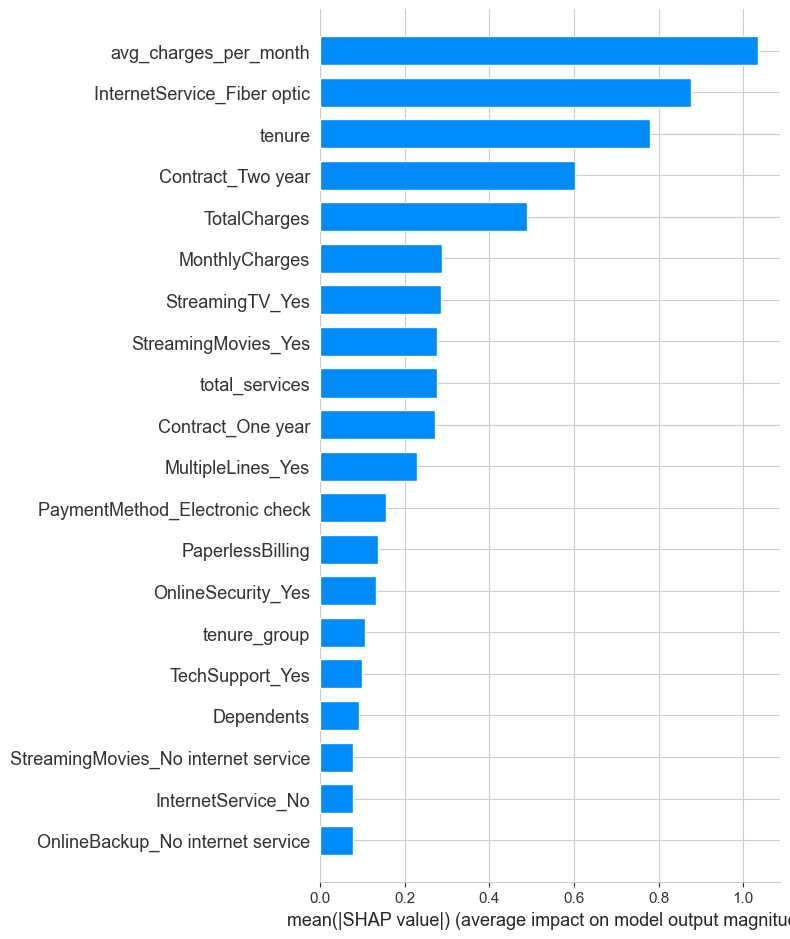

In [281]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns,
    plot_type='bar'
)

### SHAP Insights

SHAP analysis helps explain the contribution of individual features toward churn prediction.

Features with larger SHAP values have a stronger influence on model decisions.

The analysis confirms several patterns previously identified during EDA and feature importance analysis.

### SHAP Waterfall Plot

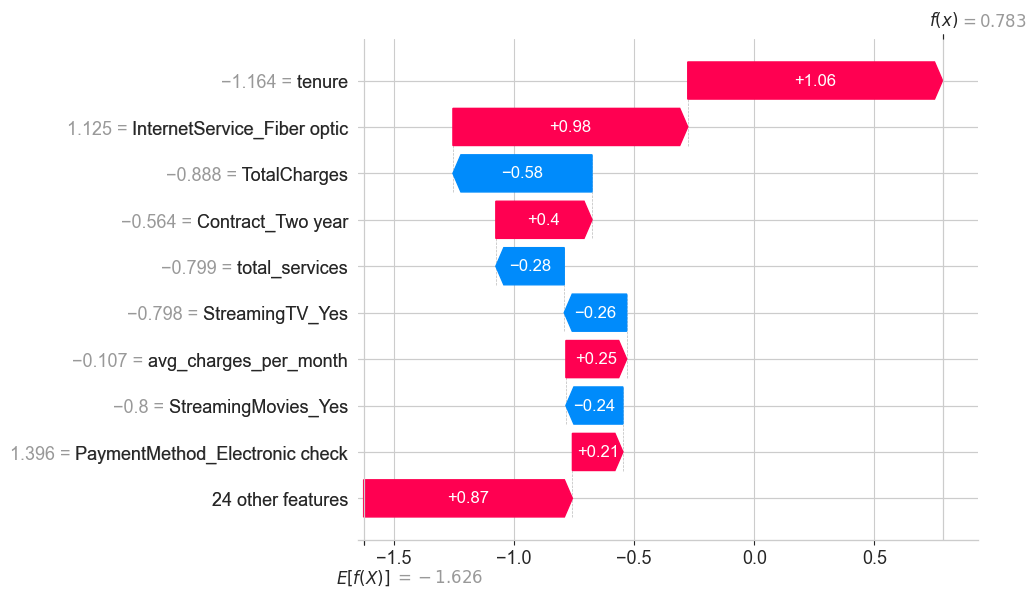

In [282]:
sample_idx = 10

sample_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled[sample_idx],
    feature_names=X.columns.tolist()
)

plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    sample_explanation,
    max_display=10
)

### Waterfall Plot Interpretation

The waterfall plot explains how individual customer attributes contribute to the final churn prediction.

Positive SHAP values increase churn probability, while negative SHAP values reduce churn probability.

For the selected customer, factors such as Fiber Optic Internet and Electronic Check payment method increased churn risk, whereas longer tenure and contract duration reduced churn risk.

This visualization provides transparency into the model's decision-making process and helps identify the key drivers behind individual predictions.


### Individual Prediction Explanation

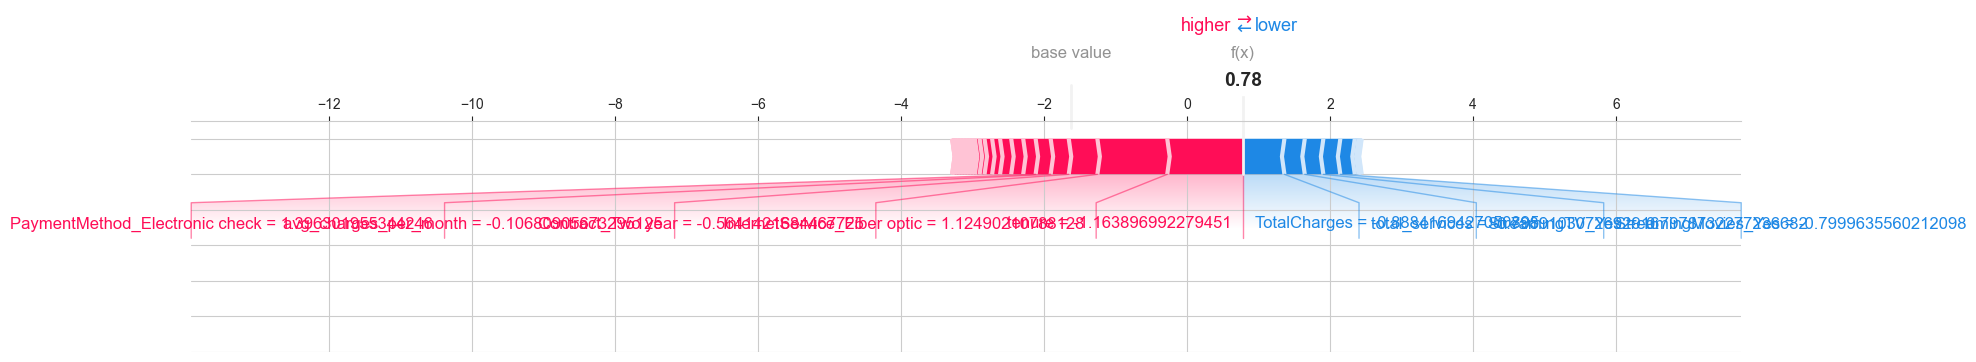

In [283]:
sample_idx = 10

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test_scaled[sample_idx],
    feature_names=X.columns,
    matplotlib=True
)

### Risk Segmentation

### Step-1: Generate Churn Probabilities

In [284]:
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

risk_df = pd.DataFrame({
    "Actual_Churn": y_test,
    "Churn_Probability": y_prob
})

risk_df.head()

,Actual_Churn,Churn_Probability
974,0,0.016275
619,0,0.607394
4289,0,0.005564
3721,1,0.197524
4533,0,0.103892


### Step-2: Create Risk Segments

In [285]:
def risk_segment(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"
    
risk_df["Risk_Segment"] = risk_df["Churn_Probability"].apply(risk_segment)

risk_df.head()

,Actual_Churn,Churn_Probability,Risk_Segment
974,0,0.016275,Low Risk
619,0,0.607394,High Risk
4289,0,0.005564,Low Risk
3721,1,0.197524,Low Risk
4533,0,0.103892,Low Risk


### Step-3: Segment Distribution

In [286]:
risk_df["Risk_Segment"].value_counts()

Risk_Segment
Low Risk       864
Medium Risk    347
High Risk      196
Name: count, dtype: int64

### Step-4: Visualize Risk Segments

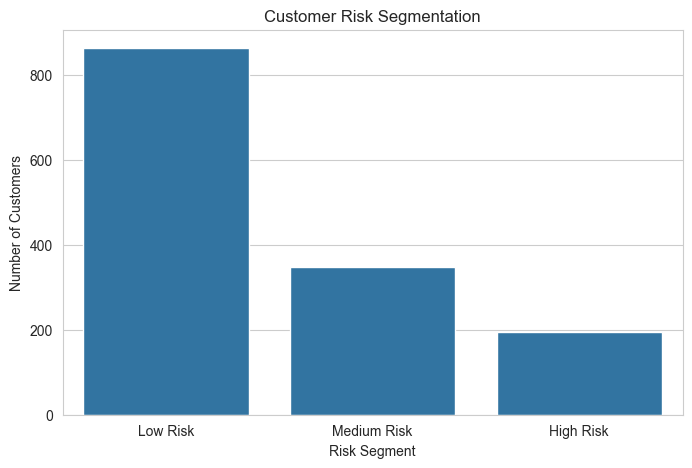

In [287]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=risk_df,
    x="Risk_Segment",
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Customer Risk Segmentation")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Customers")

plt.show()

### Step-5: Percentage Distribution

In [288]:
risk_df["Risk_Segment"].value_counts(normalize=True) * 100

Risk_Segment
Low Risk       61.407249
Medium Risk    24.662402
High Risk      13.930348
Name: proportion, dtype: float64

### Step-6: Pie Chart

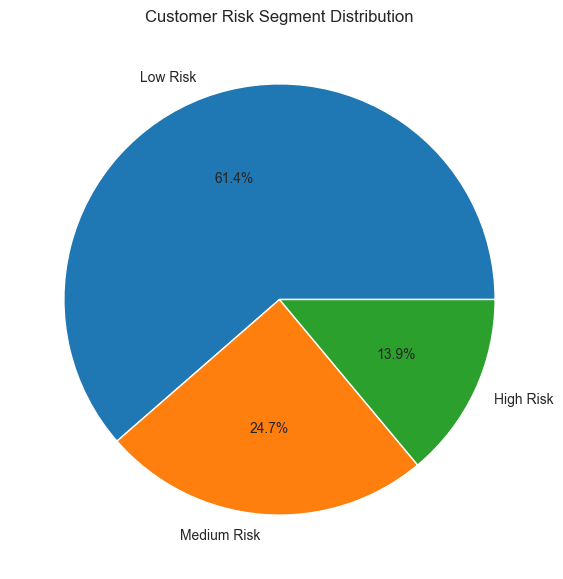

In [289]:
risk_counts = risk_df["Risk_Segment"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct="%1.1f%%"
)

plt.title("Customer Risk Segment Distribution")

plt.show()

### Step-7: Average Churn Probability per Segment

In [290]:
risk_df.groupby("Risk_Segment")["Churn_Probability"].mean()

Risk_Segment
High Risk      0.728921
Low Risk       0.098152
Medium Risk    0.454089
Name: Churn_Probability, dtype: float64

### Step-8: Visualize

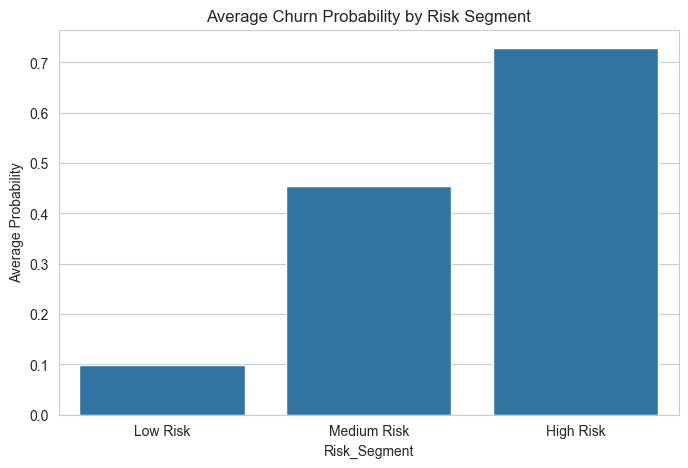

In [291]:
avg_risk = (risk_df.groupby("Risk_Segment")["Churn_Probability"].mean().reset_index())

plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_risk,
    x="Risk_Segment",
    y="Churn_Probability",
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Average Churn Probability by Risk Segment")

plt.ylabel("Average Probability")

plt.show()

### Step-9: Actual Churn Rate within each segment

In [292]:
segment_churn_rate = risk_df.groupby("Risk_Segment")["Actual_Churn"].mean() * 100

segment_churn_rate

Risk_Segment
High Risk      67.346939
Low Risk       10.416667
Medium Risk    43.804035
Name: Actual_Churn, dtype: float64

### Step-10: Visualize Actual Churn Rate

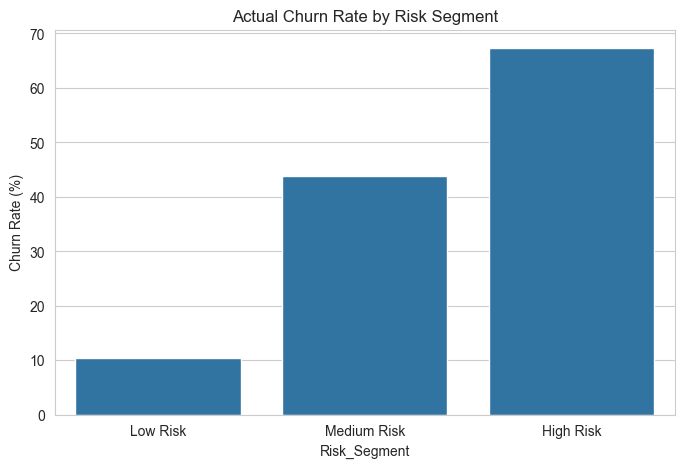

In [293]:
segment_churn_rate = (
    segment_churn_rate
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_churn_rate,
    x="Risk_Segment",
    y="Actual_Churn",
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Actual Churn Rate by Risk Segment")

plt.ylabel("Churn Rate (%)")

plt.show()

### Risk Segmentation Analysis

Customers were categorized into three groups based on predicted churn probability:

- Low Risk (<30%)
- Medium Risk (30%-60%)
- High Risk (>60%)

The model classified 61.4% of customers as Low Risk, 24.7% as Medium Risk, and 13.9% as High Risk.

The effectiveness of this segmentation was validated using actual churn outcomes:

- Low Risk customers had an actual churn rate of only 10.4%.
- Medium Risk customers exhibited a churn rate of 43.8%.
- High Risk customers showed a churn rate of 67.3%.

These results demonstrate that the model successfully separates customers according to churn risk, enabling businesses to prioritize retention efforts toward the most vulnerable customer segments.

### Retention Recommendation Engine

### Recommendation Function

In [294]:
def retention_recommendation(prob):

    if prob < 0.30:
        return "Monitor Customer"

    elif prob < 0.60:
        return "Offer Personalized Support"

    else:
        return "Priority Retention Campaign"

### Apply Recommendations

In [295]:
risk_df["Recommendation"] = risk_df[
    "Churn_Probability"
].apply(retention_recommendation)

risk_df.head()

,Actual_Churn,Churn_Probability,Risk_Segment,Recommendation
974,0,0.016275,Low Risk,Monitor Customer
619,0,0.607394,High Risk,Priority Retention Campaign
4289,0,0.005564,Low Risk,Monitor Customer
3721,1,0.197524,Low Risk,Monitor Customer
4533,0,0.103892,Low Risk,Monitor Customer


### Recommendation Distribution

In [296]:
risk_df["Recommendation"].value_counts()

Recommendation
Monitor Customer               864
Offer Personalized Support     347
Priority Retention Campaign    196
Name: count, dtype: int64

### Visualize Recommendations

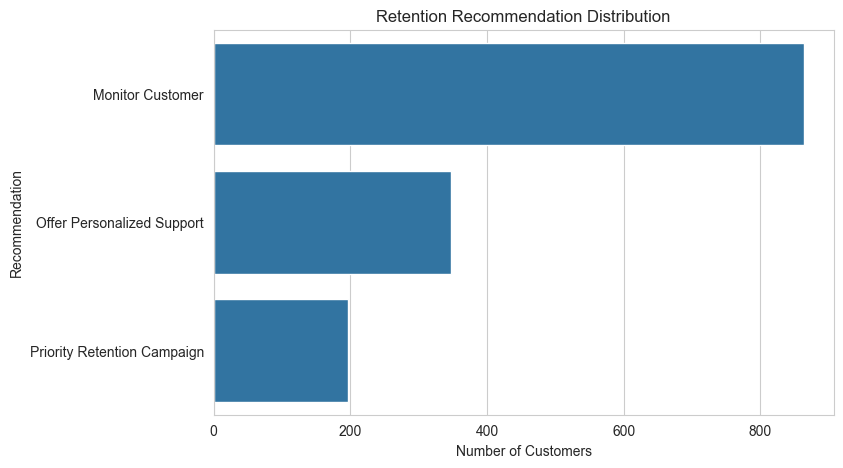

In [297]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=risk_df,
    y="Recommendation",
    order=[
        "Monitor Customer",
        "Offer Personalized Support",
        "Priority Retention Campaign"
    ]
)

plt.title("Retention Recommendation Distribution")
plt.xlabel("Number of Customers")

plt.show()

### Business Action Table

In [298]:
recommendation_summary = pd.DataFrame({

    "Risk Segment": [
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ],

    "Recommendation": [
        "Monitor Customer",
        "Offer Personalized Support",
        "Priority Retention Campaign"
    ],

    "Suggested Action": [
        "Regular engagement and monitoring",
        "Proactive customer support and targeted communication",
        "Discounts, loyalty offers, and retention outreach"
    ]
})

recommendation_summary

,Risk Segment,Recommendation,Suggested Action
0,Low Risk,Monitor Customer,Regular engagement and monitoring
1,Medium Risk,Offer Personalized Support,Proactive customer support and targeted commun...
2,High Risk,Priority Retention Campaign,"Discounts, loyalty offers, and retention outreach"


### High-Risk Customer Analysis

In [299]:
high_risk_customers = risk_df[
    risk_df["Risk_Segment"] == "High Risk"
]

print(
    "Number of High Risk Customers:",
    len(high_risk_customers)
)

high_risk_customers.head()

Number of High Risk Customers: 196


,Actual_Churn,Churn_Probability,Risk_Segment,Recommendation
619,0,0.607394,High Risk,Priority Retention Campaign
1346,1,0.626919,High Risk,Priority Retention Campaign
4283,0,0.686417,High Risk,Priority Retention Campaign
346,1,0.868081,High Risk,Priority Retention Campaign
6718,1,0.671863,High Risk,Priority Retention Campaign


### Actual Churn within High-Risk Segment

In [300]:
high_risk_actual_churn = (
    high_risk_customers["Actual_Churn"]
    .mean()
    * 100
)

print(
    f"Actual Churn Rate in High Risk Segment: "
    f"{high_risk_actual_churn:.2f}%"
)

Actual Churn Rate in High Risk Segment: 67.35%


In [301]:
for col in X.columns:
    print(col)

print(scaler.mean_.shape)
print(len(X.columns))

gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
PaperlessBilling
MonthlyCharges
TotalCharges
MultipleLines_No phone service
MultipleLines_Yes
InternetService_Fiber optic
InternetService_No
OnlineSecurity_No internet service
OnlineSecurity_Yes
OnlineBackup_No internet service
OnlineBackup_Yes
DeviceProtection_No internet service
DeviceProtection_Yes
TechSupport_No internet service
TechSupport_Yes
StreamingTV_No internet service
StreamingTV_Yes
StreamingMovies_No internet service
StreamingMovies_Yes
Contract_One year
Contract_Two year
PaymentMethod_Credit card (automatic)
PaymentMethod_Electronic check
PaymentMethod_Mailed check
tenure_group
avg_charges_per_month
total_services
(33,)
33


### Retention Recommendation Engine

A rule-based retention recommendation engine was developed using predicted churn probabilities.

Customers were categorized into three risk levels:

- Low Risk → Monitor Customer
- Medium Risk → Offer Personalized Support
- High Risk → Priority Retention Campaign

This framework converts machine learning predictions into actionable business decisions.

The High Risk segment exhibited an actual churn rate of approximately 67%, indicating that targeted retention efforts focused on this group could substantially reduce customer attrition while optimizing retention resources.

### Error Analysis
### Generate Predictions

In [302]:
final_threshold = 0.40

y_prob = log_reg.predict_proba(X_test_scaled)[:,1]

y_pred = (y_prob >= final_threshold).astype(int)

### Confusion Matrix

In [303]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[853, 180],
       [120, 254]], dtype=int64)

### Visualize

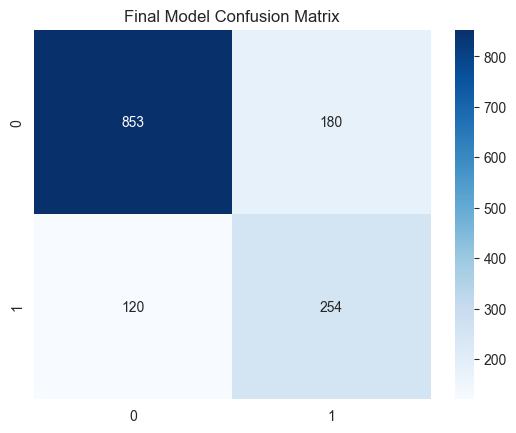

In [304]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Final Model Confusion Matrix")

plt.show()

### False Positives
Customers predicted to churn but actually stayed

In [305]:
false_positive_idx = X_test.index[
(y_test == 0) & (y_pred == 1)
]

false_positive_cases = df_encoded.loc[false_positive_idx]

false_positive_cases.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,avg_charges_per_month,total_services
619,0,0,0,0,7,1,1,78.55,522.95,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,65.368750,4
4283,1,1,1,0,4,1,1,70.20,280.35,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,56.070000,2
6128,0,0,1,0,14,1,1,78.10,1122.40,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,74.826667,3
5384,0,0,0,0,4,1,1,64.40,253.00,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,50.600000,4
559,1,0,0,0,1,1,1,49.30,49.30,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,24.650000,2


In [306]:
false_positive_cases.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,avg_charges_per_month,total_services
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.0,180.000000,180.000000,180.000000,180.0,180.0,180.000000,180.0,180.000000,180.0,180.000000,180.0,180.000000,180.0,180.000000,180.0,180.000000,180.000000,180.0,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,0.505556,0.277778,0.283333,0.105556,15.783333,0.894444,0.733333,76.325000,1377.594167,0.0,0.105556,0.494444,0.744444,0.0,0.0,0.072222,0.0,0.266667,0.0,0.305556,0.0,0.105556,0.0,0.444444,0.0,0.433333,0.011111,0.0,0.155556,0.561111,0.211111,0.727778,65.128465,3.761111
std,0.501364,0.449153,0.451874,0.308125,16.466412,0.308125,0.443450,20.465908,1623.510832,0.0,0.308125,0.501364,0.437390,0.0,0.0,0.259578,0.0,0.443450,0.0,0.461927,0.0,0.308125,0.0,0.498290,0.0,0.496918,0.105114,0.0,0.363444,0.497636,0.409235,0.944437,24.777023,1.718658
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,24.200000,24.200000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,12.100000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,69.062500,217.775000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,47.152415,2.000000
50%,1.000000,0.000000,0.000000,0.000000,9.000000,1.000000,1.000000,79.800000,658.775000,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,1.000000,0.000000,0.000000,69.461071,4.000000
75%,1.000000,1.000000,1.000000,0.000000,23.250000,1.000000,1.000000,91.075000,2000.437500,0.0,0.000000,1.000000,1.000000,0.0,0.0,0.000000,0.0,1.000000,0.0,1.000000,0.0,0.000000,0.0,1.000000,0.0,1.000000,0.000000,0.0,0.000000,1.000000,0.000000,1.000000,84.037500,5.000000
max,1.000000,1.000000,1.000000,1.000000,68.000000,1.000000,1.000000,108.900000,7082.450000,0.0,1.000000,1.000000,1.000000,0.0,0.0,1.000000,0.0,1.000000,0.0,1.000000,0.0,1.000000,0.0,1.000000,0.0,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,3.000000,107.309848,8.000000


### False Negatives
Customers predicted to stay but actually churned

In [307]:
false_negative_idx = X_test.index[
(y_test == 1) & (y_pred == 0)
]

false_negative_cases = df_encoded.loc[false_negative_idx]

false_negative_cases.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,avg_charges_per_month,total_services
3721,0,0,0,0,2,1,0,20.65,38.70,1,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,1,0,12.900000,1
4653,0,0,1,1,30,0,0,51.20,1561.50,1,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,0,2,50.370968,3
2300,0,0,1,1,48,1,1,103.25,5037.55,1,0,1,1,0,0,1,0,1,0,0,0,0,0,1,0,1,1,0,1,0,0,2,102.807143,7
978,1,1,1,0,62,1,1,103.75,6383.35,1,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,1,1,0,0,1,0,3,101.323016,7
5738,1,0,0,0,1,1,0,20.60,20.60,1,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,1,0,10.300000,1


In [308]:
false_negative_cases.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,avg_charges_per_month,total_services
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.0,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.00000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,0.516667,0.158333,0.541667,0.375000,27.966667,0.908333,0.591667,64.256667,2285.590833,1.0,0.091667,0.325000,0.400000,0.200000,0.200000,0.316667,0.200000,0.383333,0.200000,0.275000,0.200000,0.316667,0.200000,0.391667,0.200000,0.408333,0.325000,0.066667,0.17500,0.266667,0.283333,1.375000,59.606678,3.725000
std,0.501817,0.366584,0.500350,0.486153,22.467505,0.289765,0.493586,30.246874,2248.722174,0.0,0.289765,0.470339,0.491952,0.401677,0.401677,0.467127,0.401677,0.488237,0.401677,0.448386,0.401677,0.467127,0.401677,0.490169,0.401677,0.493586,0.470339,0.250490,0.38156,0.444071,0.452506,1.195668,32.356999,2.260224
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.850000,18.850000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,9.425000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,6.000000,1.000000,0.000000,45.237500,216.912500,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,35.629062,2.000000
50%,1.000000,0.000000,1.000000,0.000000,24.500000,1.000000,1.000000,61.975000,1742.450000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.500000,59.803647,4.000000
75%,1.000000,0.000000,1.000000,1.000000,48.000000,1.000000,1.000000,91.100000,3506.762500,1.0,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.00000,1.000000,1.000000,2.000000,89.695891,6.000000
max,1.000000,1.000000,1.000000,1.000000,69.000000,1.000000,1.000000,113.150000,7856.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,3.000000,113.855072,9.000000


### Business Recommendations

### Recommendation 1: Promote Long-Term Contracts

Customers with month-to-month contracts showed significantly higher churn rates.

Offering incentives for annual and multi-year contracts could improve retention.

### Recommendation 2: Expand Technical Support Services

Customers with technical support subscriptions exhibited lower churn rates.

Providing proactive support and troubleshooting services may reduce customer dissatisfaction.

### Recommendation 3: Target High-Risk Fiber Customers

Fiber optic customers showed elevated churn risk.

Investigating pricing, service quality, and competitor offerings may improve retention.

### Recommendation 4: Retention Campaigns for New Customers

Customers with shorter tenure exhibited higher churn probability.

Early engagement programs may improve long-term loyalty.

# Executive Summary

This project developed a machine learning solution to predict customer churn and identify key retention opportunities.

After evaluating six machine learning models, Logistic Regression emerged as the strongest overall performer. Threshold optimization further improved the balance between precision and recall, resulting in a final model capable of identifying a substantial proportion of at-risk customers.

Key findings include:

- Fiber optic customers exhibit higher churn risk.
- Month-to-month contracts strongly increase churn probability.
- Longer customer tenure significantly reduces churn risk.
- Technical support services improve customer retention.

The final model achieved:
- Precision: 58.5%
- Recall: 67.9%
- F1 Score: 62.9%
- ROC-AUC: 83.8%

These findings can help telecom companies proactively identify high-risk customers and implement targeted retention strategies.

# Conclusion

Customer churn prediction is not solely a machine learning challenge but also a business decision-making problem.

Through exploratory data analysis, feature engineering, model comparison, hyperparameter tuning, threshold optimization, and explainability analysis, this project identified the primary drivers of customer churn and developed a practical predictive model.

The final Logistic Regression model demonstrated strong predictive performance while remaining highly interpretable, making it suitable for real-world customer retention initiatives.